In [1]:
import os
import sys
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
#import nipes_data_fcts as nidf
import me_data_fcts as medf
#from statannotations.Annotator import Annotator
import umap
from sklearn.preprocessing import StandardScaler


In [2]:
# if you modify me_data_fcts.py and want to reload without restarting the kernel
import importlib
importlib.reload(medf)

<module 'me_data_fcts' from '/home/leni/git/AREFramework/experiments/scripts/me_data_fcts.py'>

# SQ_CPPN

In [3]:
repo_folder = "/media/leni/DATADRIVE1/gecco_2026/env_pressure_full/"
experiments = {
    "directory" :  ['meimflat', 'meim_sq_hill', 'meimholes', 'meimobs', 'meimrough', 'meimholly' ],
    "name" :       ['flat', 'hill', 'holes', 'obstacles', 'rough', 'holyrood'],
    "print_name" : ['Flat', 'Hill', 'Holes', 'Obstacles', 'Rough', 'Holyrood'],
}

In [4]:
def load_experiment(name, folders):
    experiments_loaded = 0
    exp_fits = []
    for folder in folders:
        #print(folder)
        ids, parents, fitnesses, evals, deltas, replicate_index = medf.load_fitness(folder + "/fitness.csv")
        eval_times = medf.load_comp_time_dict(folder + "/times.csv")
        fits = [[i, p[0], p[1], eval_times[i][0]/(1000000*3600), eval_times[i][1]/(1000000*3600), f, folder, r] 
                for i, p, f, r in zip(ids,parents,fitnesses, replicate_index)]
        exp_fits += fits
        experiments_loaded += 1
        print(folder, " -- Robots: ", len(ids))
    fit_data = pd.DataFrame(data=exp_fits,columns=[      "robot index",
                                                         "parent 1",
                                                         "parent 2",
                                                         "evaluation time",
                                                         "time",
                                                         "fitness",
                                                         "replicate", 
                                                         "replicate_index"])
    fit_data["environment"] = name
    print("Total experiments loaded: ", experiments_loaded, "-- Total robots: ", len(fit_data))
    return fit_data

In [5]:
def load_morphology(name, folders):
    exp_descs = []
    experiments_loaded = 0
    for folder in folders:
        #parent_ids = medf.load_parent_pool(folder + "/parent_pool.csv")
        descriptors = medf.load_feature_descriptor(folder + "/morph_features.csv")
        #print(descriptors[-1])
        descs = [[int(d[0])] + d[1:5] + [d[5]*16,
                                         d[6]*16,
                                         d[7]*16,
                                         d[8]*16]
                                           + d[9:]  + [folder] 
                 for d in descriptors]
        #print(descs[-1])
        #parent_descs += medf.filter_to_parent_pool(descs,parent_ids)
        exp_descs += descs        
        print(folder, " -- Robots: ", len(descs))
        experiments_loaded += 1
    data = pd.DataFrame(data=exp_descs,columns=[
                                                            "robot index",
                                                            "width",
                                                            "depth",
                                                            "height",
                                                            "voxels",
                                                            "wheels",
                                                            "sensors",
                                                            "limbs",
                                                            "casters",
                                                            "norm",
                                                            "skeleton norm",
                                                            "components norm",
                                                            "replicate_index", 
                                                            "replicate"])
    data["environment"] = name
    print("Total experiments loaded: ", experiments_loaded, "-- Total robots: ", len(data))
    return data

In [6]:
# Load fitness data
robot_data = []
for idx, exps in enumerate(experiments['directory']):
    print(exps)
    folders = []
    data = []
    for folder in os.listdir(repo_folder + exps):
        
        folders.append(repo_folder + exps + '/' + folder)
    data = load_experiment(experiments['name'][idx], folders)
    robot_data.append(data)


meimflat
/media/leni/DATADRIVE1/gecco_2026/env_pressure_full/meimflat/meim_11_3_17-59-56-6384-2102594713  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/env_pressure_full/meimflat/meim_11_3_17-59-57-7269-4229270083  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/env_pressure_full/meimflat/meim_11_3_17-59-57-7377-2053156979  -- Robots:  10036
/media/leni/DATADRIVE1/gecco_2026/env_pressure_full/meimflat/meim_11_3_17-59-57-7467-1188062065  -- Robots:  10002
/media/leni/DATADRIVE1/gecco_2026/env_pressure_full/meimflat/meim_11_3_17-59-57-7862-293875990  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/env_pressure_full/meimflat/meim_11_3_17-59-58-8527-4068923784  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/env_pressure_full/meimflat/meim_11_3_17-59-59-9003-1516430376  -- Robots:  10024
/media/leni/DATADRIVE1/gecco_2026/env_pressure_full/meimflat/meim_11_3_19-16-10-816-2370462392  -- Robots:  10046
/media/leni/DATADRIVE1/gecco_2026/env_pressure_full/meimflat/meim_12_3_1-

In [7]:
# loading descriptor data
robot_desc_data = []
for idx, exps in enumerate(experiments['directory']):
    print(exps)
    folders = []
    data = []
    for folder in os.listdir(repo_folder + exps):
        folders.append(repo_folder + exps + '/' + folder)
    data = load_morphology(experiments['name'][idx], folders)
    robot_desc_data.append(data)

meimflat
/media/leni/DATADRIVE1/gecco_2026/env_pressure_full/meimflat/meim_11_3_17-59-56-6384-2102594713  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/env_pressure_full/meimflat/meim_11_3_17-59-57-7269-4229270083  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/env_pressure_full/meimflat/meim_11_3_17-59-57-7377-2053156979  -- Robots:  10036
/media/leni/DATADRIVE1/gecco_2026/env_pressure_full/meimflat/meim_11_3_17-59-57-7467-1188062065  -- Robots:  10002
/media/leni/DATADRIVE1/gecco_2026/env_pressure_full/meimflat/meim_11_3_17-59-57-7862-293875990  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/env_pressure_full/meimflat/meim_11_3_17-59-58-8527-4068923784  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/env_pressure_full/meimflat/meim_11_3_17-59-59-9003-1516430376  -- Robots:  10024
/media/leni/DATADRIVE1/gecco_2026/env_pressure_full/meimflat/meim_11_3_19-16-10-816-2370462392  -- Robots:  10046
/media/leni/DATADRIVE1/gecco_2026/env_pressure_full/meimflat/meim_12_3_1-

In [8]:
# Concat all the parents data
fit_data = pd.concat(robot_data).reset_index(drop=True)
#fit_data = fit_data[fit_data["replicate_index"] <= 6000]

# Selecting highest robot per replicate
fit_max_data = []
for env in experiments["name"]:
    tmp_data = fit_data.loc[fit_data["environment"] == env]
    for rep in tmp_data["replicate"].drop_duplicates():
        tmp_data2 = tmp_data.loc[tmp_data["replicate"] == rep]
        fit_max_data.append(pd.DataFrame(tmp_data2.max(numeric_only=True)).transpose())
        fit_max_data[-1]["replicate"] = rep
        fit_max_data[-1]["environment"] = env
            
fit_max_data = pd.concat(fit_max_data)
fit_max_data.index = [i for i in range(len(fit_max_data))]

In [9]:
desc_data = pd.concat(robot_desc_data).reset_index(drop=True)
desc_data = pd.merge(desc_data, fit_data, how="left",
                     on=["robot index", "replicate", "environment", "replicate_index"])
desc_data = desc_data.drop_duplicates(subset=['robot index','replicate'])
#desc_data = desc_data[desc_data["replicate_index"] <= 6000]


## Exploration score

/tmp/ipykernel_2234792/2931069552.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(experiments["print_name"])


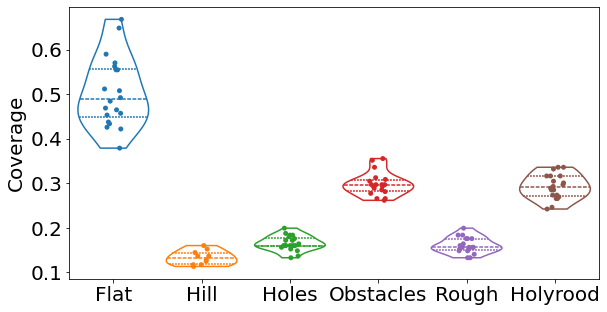

In [53]:
fig = plt.gcf()
fig.set_size_inches(9.5,5)
ax = sns.violinplot(fit_max_data,x="environment",hue="environment",y="fitness",fill=False,inner="quart", cut=0)
sns.stripplot(fit_max_data,x="environment",hue="environment",y="fitness")
ax.set_xlabel("")
ax.set_xticklabels(experiments["print_name"])
ax.set_ylabel("Coverage")
ax.xaxis.label.set_size(20)
ax.yaxis.label.set_size(20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.savefig("img_alife25/exploration_score.png")


In [54]:
avg_fitness_per_replicate_index = fit_data.groupby(['environment', 'replicate_index'])['fitness'].mean().reset_index()
avg_fitness_per_replicate_index.rename(columns={'fitness': 'average_fitness'}, inplace=True)
avg_fitness_per_replicate_index

,environment,replicate_index,average_fitness
0,flat,0,0.022852
1,flat,1,0.030664
2,flat,2,0.032422
3,flat,3,0.028906
4,flat,4,0.031836
...,...,...,...
60270,rough,10043,0.028646
60271,rough,10044,0.021484
60272,rough,10045,0.021484
60273,rough,10046,0.042969


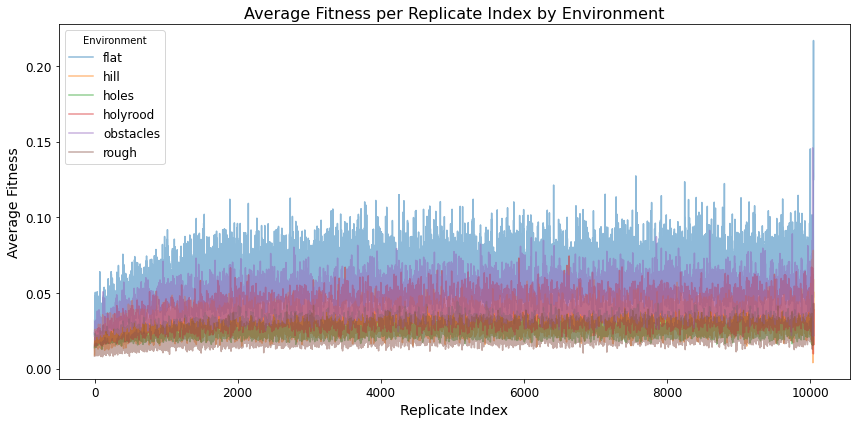

<Figure size 432x288 with 0 Axes>

In [55]:
fig = plt.gcf()
fig.set_size_inches(12, 6)
ax = sns.lineplot(
  data=avg_fitness_per_replicate_index,
  x="replicate_index",
  y="average_fitness",
  hue="environment",
  alpha=0.5
)
ax.set_title("Average Fitness per Replicate Index by Environment", fontsize=16)
ax.set_xlabel("Replicate Index", fontsize=14)
ax.set_ylabel("Average Fitness", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title="Environment", fontsize=12)
plt.tight_layout()
plt.show()
plt.savefig("img_alife25/fitness.png")


## Components diversity

(array([0. , 0.1, 0.2, 0.3, 0.4, 0.5]),
 [Text(0, 0.0, '0%'),
  Text(0, 0.1, '10%'),
  Text(0, 0.2, '20%'),
  Text(0, 0.30000000000000004, '30%'),
  Text(0, 0.4, '40%'),
  Text(0, 0.5, '50%')])

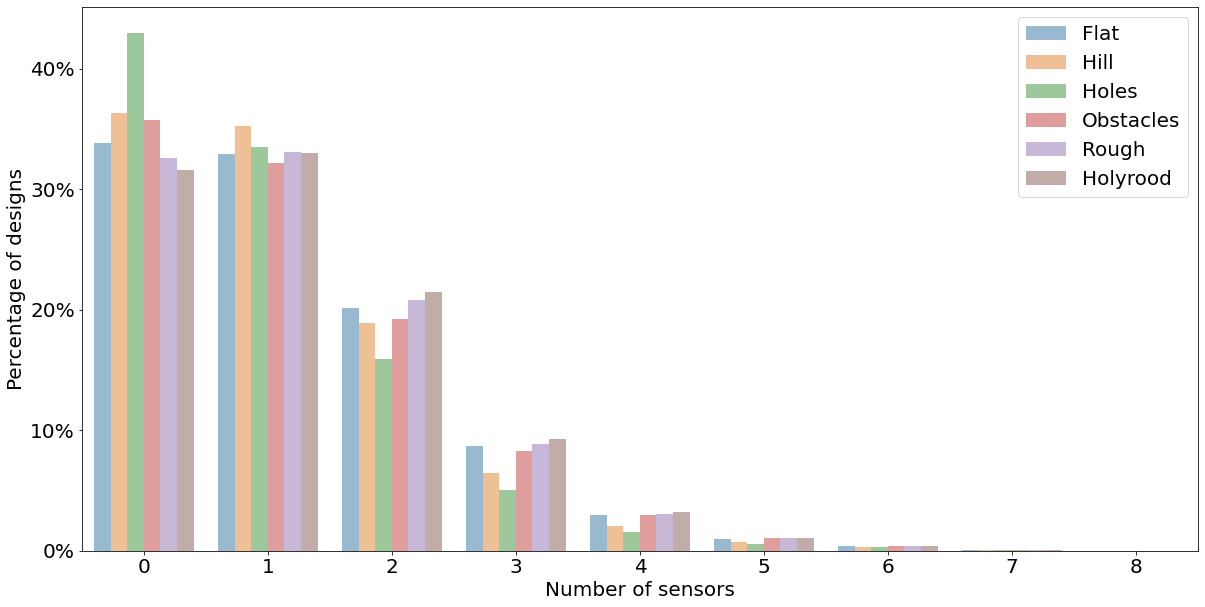

In [56]:
fig = plt.gcf()
fig.set_size_inches(20,10)
df = pd.crosstab(desc_data['environment'], desc_data['sensors'], normalize='index')
df1 = df.melt(var_name='sensors', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="sensors",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5)
ax.yaxis.label.set_size(20)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Number of sensors")
ax.set_ylabel("Percentage of designs")
ax.yaxis.label.set_size(20)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=20)

(array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 ]),
 [Text(0, 0.0, '0%'),
  Text(0, 0.05, '5%'),
  Text(0, 0.1, '10%'),
  Text(0, 0.15000000000000002, '15%'),
  Text(0, 0.2, '20%'),
  Text(0, 0.25, '25%'),
  Text(0, 0.30000000000000004, '30%'),
  Text(0, 0.35000000000000003, '35%'),
  Text(0, 0.4, '40%')])

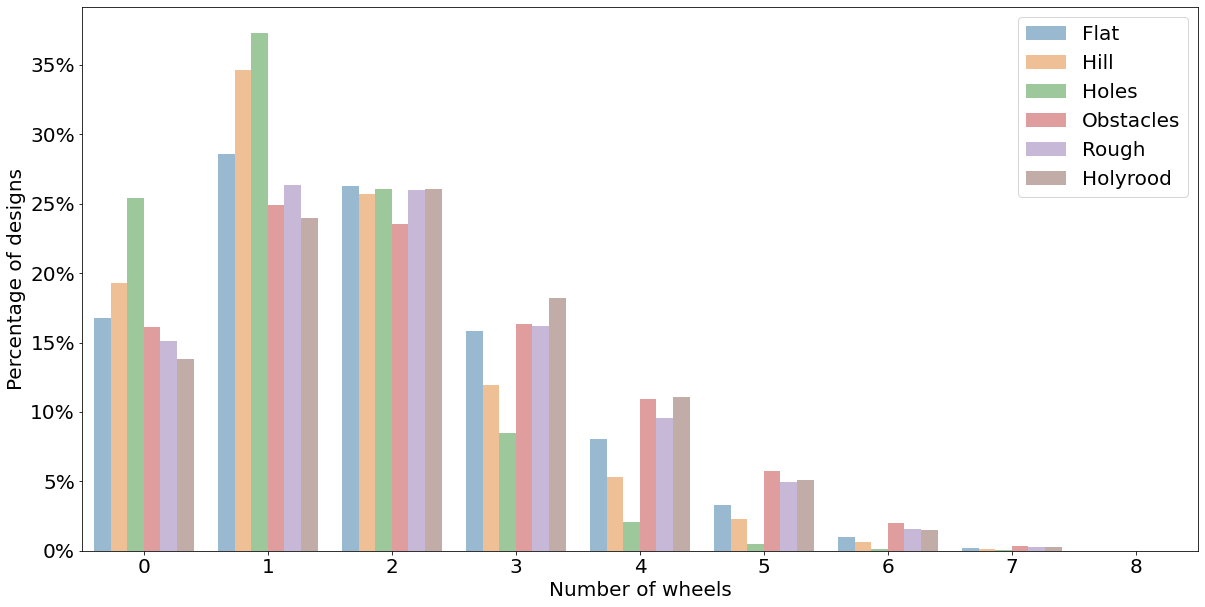

In [57]:
fig = plt.gcf()
fig.set_size_inches(20,10)
df = pd.crosstab(desc_data['environment'], desc_data['wheels'], normalize='index')
df1 = df.melt(var_name='wheels', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="wheels",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5)
ax.yaxis.label.set_size(20)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Number of wheels")
ax.set_ylabel("Percentage of designs")
ax.yaxis.label.set_size(20)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=20)

(array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]),
 [Text(0, 0.0, '0%'),
  Text(0, 0.1, '10%'),
  Text(0, 0.2, '20%'),
  Text(0, 0.30000000000000004, '30%'),
  Text(0, 0.4, '40%'),
  Text(0, 0.5, '50%'),
  Text(0, 0.6000000000000001, '60%'),
  Text(0, 0.7000000000000001, '70%')])

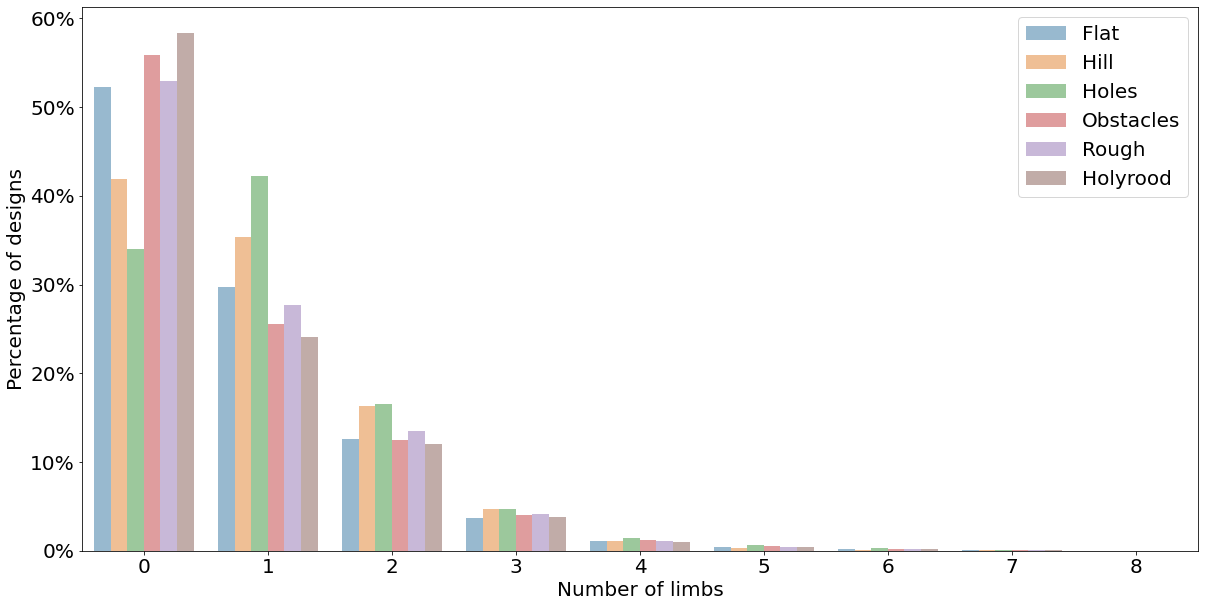

In [58]:
fig = plt.gcf()
fig.set_size_inches(20,10)
df = pd.crosstab(desc_data['environment'], desc_data['limbs'], normalize='index')
df1 = df.melt(var_name='limbs', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="limbs",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5)
ax.yaxis.label.set_size(20)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Number of limbs")
ax.set_ylabel("Percentage of designs")
ax.yaxis.label.set_size(20)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=20)

(array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]),
 [Text(0, 0.0, '0%'),
  Text(0, 0.1, '10%'),
  Text(0, 0.2, '20%'),
  Text(0, 0.30000000000000004, '30%'),
  Text(0, 0.4, '40%'),
  Text(0, 0.5, '50%'),
  Text(0, 0.6000000000000001, '60%'),
  Text(0, 0.7000000000000001, '70%'),
  Text(0, 0.8, '80%')])

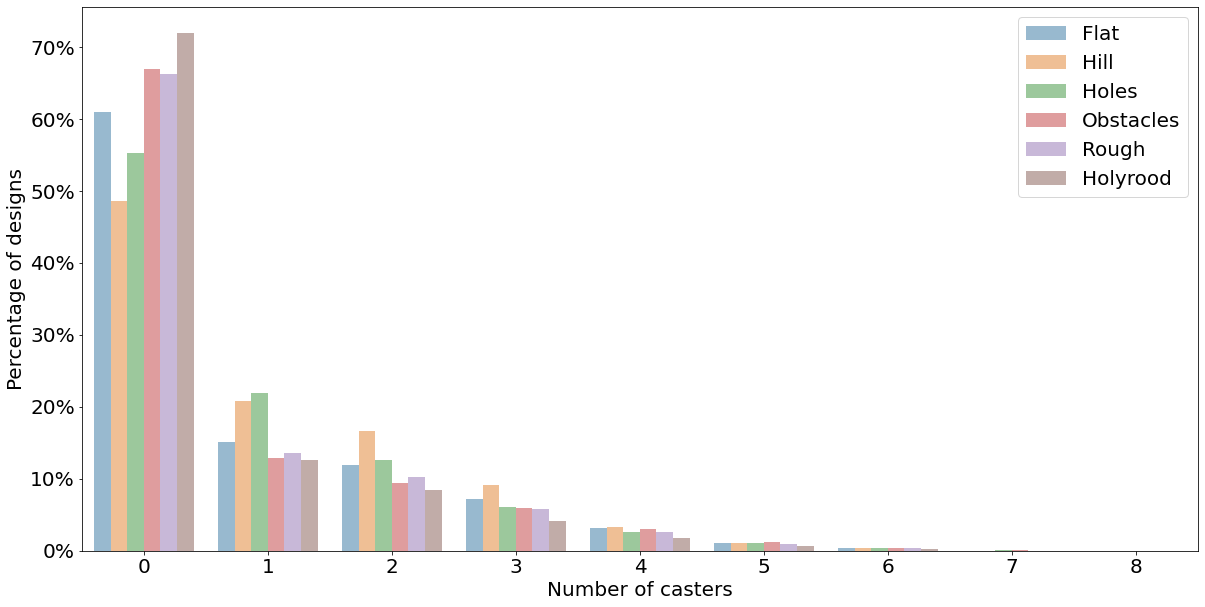

In [59]:
fig = plt.gcf()
fig.set_size_inches(20,10)
df = pd.crosstab(desc_data['environment'], desc_data['casters'], normalize='index')
df1 = df.melt(var_name='casters', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="casters",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5)
ax.yaxis.label.set_size(20)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Number of casters")
ax.set_ylabel("Percentage of designs")
ax.yaxis.label.set_size(20)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=20)

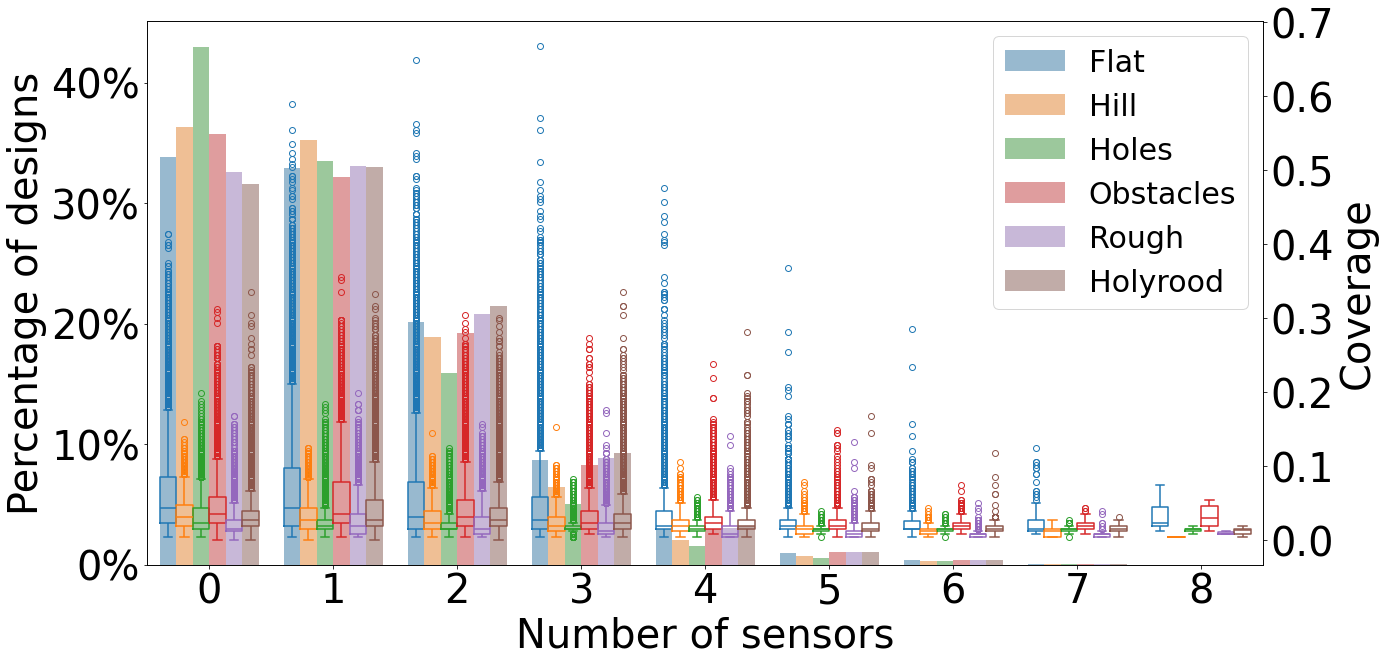

In [60]:
fig = plt.gcf()
fig.set_size_inches(20,10)
df = pd.crosstab(desc_data['environment'], desc_data['sensors'], normalize='index')
df1 = df.melt(var_name='sensors', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="sensors",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5)
ax.yaxis.label.set_size(40)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=30)
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
ax.xaxis.label.set_size(40)
ax.set_xlabel("Number of sensors")
ax.set_ylabel("Percentage of designs")
ax = plt.twinx()
sns.boxplot(data=desc_data,x="sensors",y="fitness",hue="environment",ax=ax,fill=False,legend=False)
ax.set_ylabel("Coverage")
ax.yaxis.label.set_size(40)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=40)
plt.savefig("img_alife25/distribution_sensors_score.png")

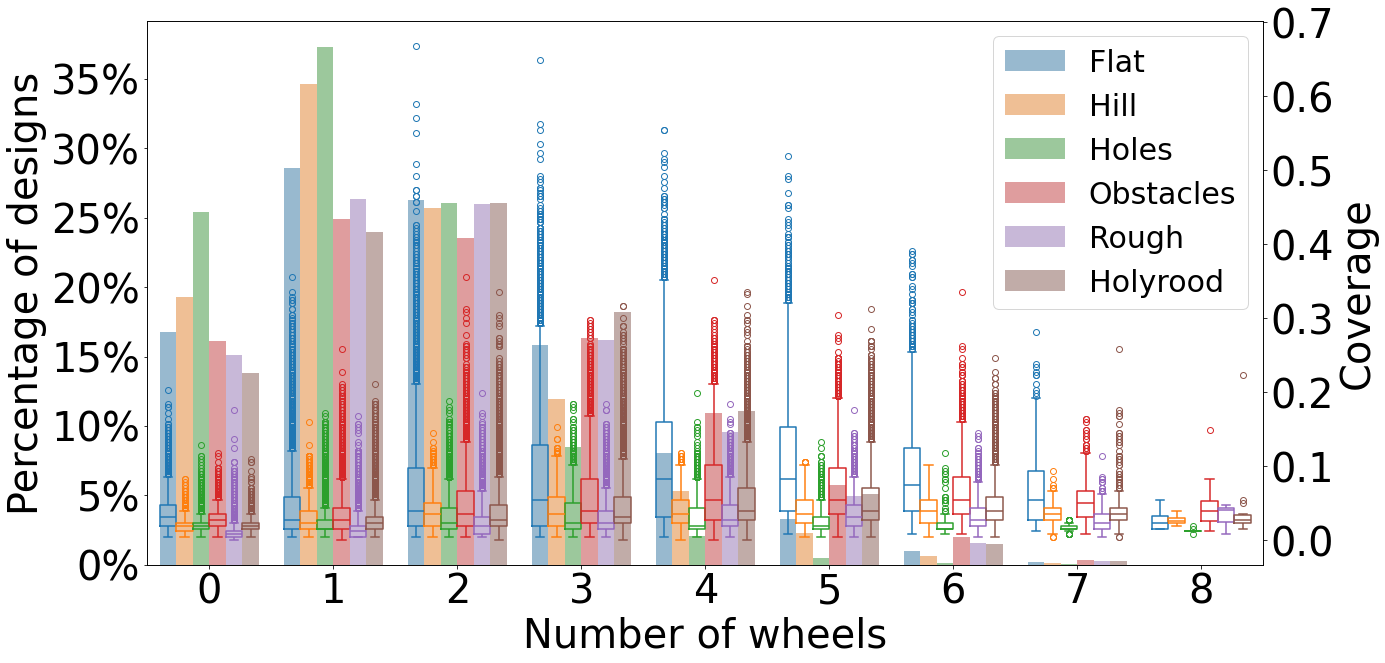

In [61]:
fig = plt.gcf()
fig.set_size_inches(20,10)
df = pd.crosstab(desc_data['environment'], desc_data['wheels'], normalize='index')
df1 = df.melt(var_name='wheels', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="wheels",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5)
ax.yaxis.label.set_size(40)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=30)
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
ax.xaxis.label.set_size(40)
ax.set_xlabel("Number of wheels")
ax.set_ylabel("Percentage of designs")
ax = plt.twinx()
sns.boxplot(data=desc_data,x="wheels",y="fitness",hue="environment",ax=ax,fill=False,legend=False)
ax.set_ylabel("Coverage")
ax.yaxis.label.set_size(40)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=40)
plt.savefig("img_alife25/distribution_wheels_score.png")

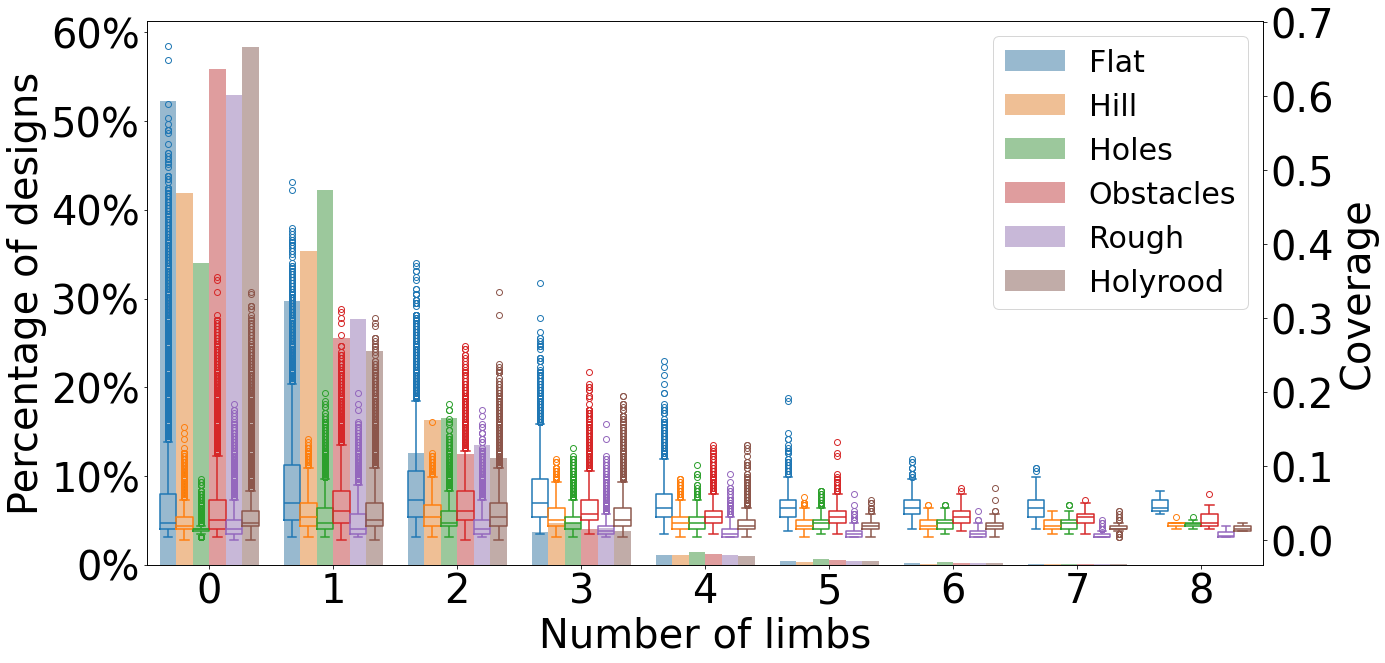

In [62]:
fig = plt.gcf()
fig.set_size_inches(20,10)
df = pd.crosstab(desc_data['environment'], desc_data['limbs'], normalize='index')
df1 = df.melt(var_name='limbs', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="limbs",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5)
ax.yaxis.label.set_size(40)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=30)
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
ax.xaxis.label.set_size(40)
ax.set_xlabel("Number of limbs")
ax.set_ylabel("Percentage of designs")
ax = plt.twinx()
sns.boxplot(data=desc_data,x="limbs",y="fitness",hue="environment",ax=ax,fill=False,legend=False)
ax.set_ylabel("Coverage")
ax.yaxis.label.set_size(40)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=40)
plt.savefig("img_alife25/distribution_limbs_score.png")

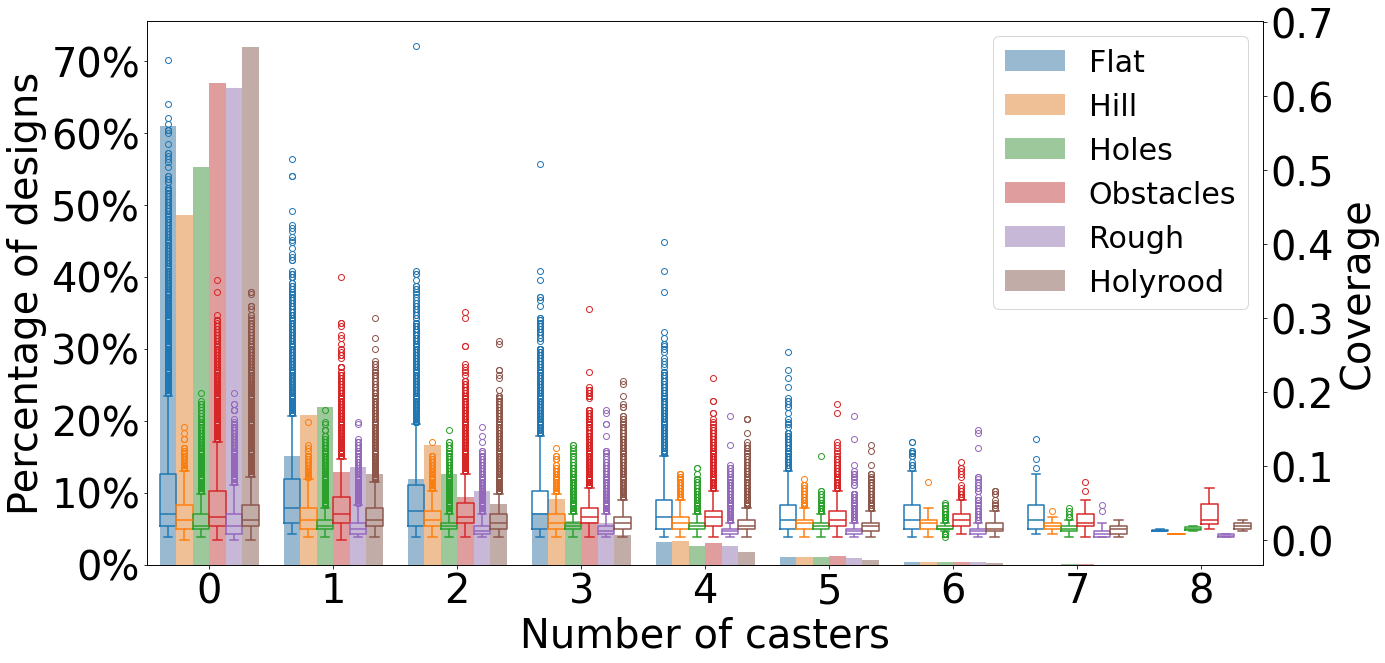

In [63]:
fig = plt.gcf()
fig.set_size_inches(20,10)
df = pd.crosstab(desc_data['environment'], desc_data['casters'], normalize='index')
df1 = df.melt(var_name='casters', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="casters",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5)
ax.yaxis.label.set_size(40)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=30)
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
ax.xaxis.label.set_size(40)
ax.set_xlabel("Number of casters")
ax.set_ylabel("Percentage of designs")
ax = plt.twinx()
sns.boxplot(data=desc_data,x="casters",y="fitness",hue="environment",ax=ax,fill=False,legend=False)
ax.set_ylabel("Coverage")
ax.yaxis.label.set_size(40)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=40)
plt.savefig("img_alife25/distribution_casters_score.png")

## High coverage diversity

In [10]:
top_percent = 0.1

df_top = []
for idx, exp in enumerate(experiments["name"]):
     df_top_tmp = desc_data[desc_data.environment.isin([exp])].sort_values(by='fitness', ascending=False)
     df_top_tmp = df_top_tmp.head(int(len(df_top_tmp)*(top_percent/100)))
     print(len(df_top_tmp))
     df_top.append(df_top_tmp)

df_top_desc_data = pd.concat(df_top).reset_index(drop=True)
print(len(df_top_desc_data.index))

200
100
200
190
190
200
1080


In [11]:
top_percent = 1

df_top = []
for idx, exp in enumerate(experiments["name"]):
     df_tmp = desc_data[desc_data.environment.isin([exp])]
     for rep in df_tmp["replicate"].drop_duplicates():
          df_tmp1 = df_tmp.loc[df_tmp["replicate"] == rep]
          df_top_tmp = df_tmp1.sort_values(by='fitness', ascending=False)
          df_top_tmp = df_top_tmp.head(int(len(df_top_tmp)*(top_percent/100)))
          print(exp,len(df_top_tmp),df_top_tmp.max()["fitness"],df_top_tmp.min()["fitness"])
          df_top.append(df_top_tmp)

df_top = pd.concat(df_top).reset_index(drop=True)
print(len(df_top.index))

flat 100 0.5625 0.300781
flat 100 0.589844 0.308594
flat 100 0.425781 0.246094
flat 100 0.507812 0.273438
flat 100 0.421875 0.253906
flat 100 0.648438 0.273438
flat 100 0.554688 0.304688
flat 100 0.511719 0.304688
flat 100 0.464844 0.25
flat 100 0.492188 0.253906
flat 100 0.667969 0.265625
flat 100 0.4375 0.230469
flat 100 0.378906 0.214844
flat 100 0.453125 0.296875
flat 100 0.554688 0.289062
flat 100 0.457031 0.269531
flat 100 0.46875 0.300781
flat 100 0.433594 0.25
flat 100 0.484375 0.28125
flat 100 0.570312 0.277344
hill 100 0.125 0.0898438
hill 100 0.117188 0.0859375
hill 100 0.152344 0.09375
hill 100 0.117188 0.0898438
hill 100 0.136719 0.0859375
hill 100 0.136719 0.09375
hill 100 0.160156 0.0898438
hill 100 0.113281 0.0898438
hill 100 0.128906 0.0898438
hill 100 0.144531 0.0859375
holes 100 0.152344 0.0898438
holes 100 0.160156 0.09375
holes 100 0.1875 0.0859375
holes 100 0.171875 0.0898438
holes 100 0.160156 0.0898438
holes 100 0.160156 0.0859375
holes 100 0.179688 0.101562
hol

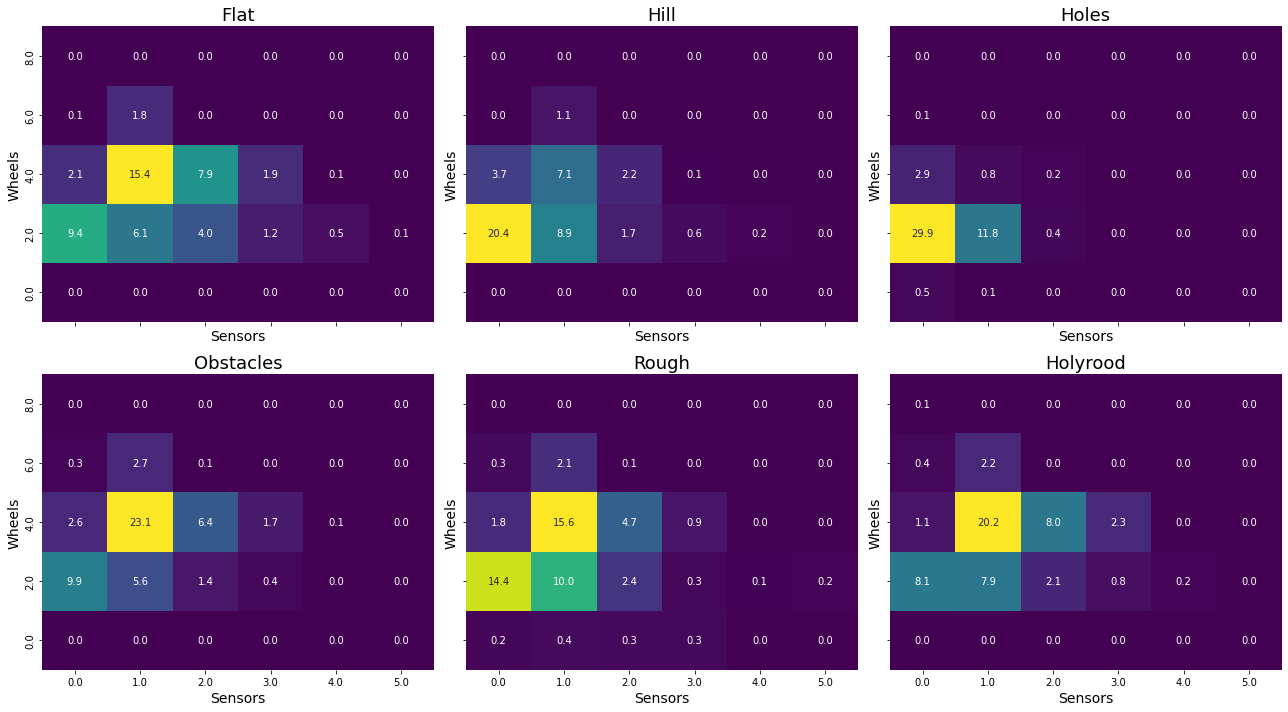

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for idx, env in enumerate(experiments["name"]):
    ax = axes[idx // 3, idx % 3]
    data = df_top[df_top["environment"] == env]
    joint_counts = pd.crosstab(data['wheels'], data['sensors'], normalize='all') * 100
    sensors_vals = sorted(df_top['sensors'].unique())
    limbs_vals = sorted(df_top['limbs'].unique())
    joint_counts = joint_counts.reindex(index=limbs_vals, columns=sensors_vals, fill_value=0.0)
    sns.heatmap(joint_counts, annot=True, fmt='.1f', cmap='viridis',
                xticklabels=True, yticklabels=True, cbar=False, ax=ax)
    ax.set_title(experiments["print_name"][idx], fontsize=18)
    ax.set_xlabel('Sensors', fontsize=14)
    ax.set_ylabel('Wheels', fontsize=14)
    ax.invert_yaxis()
    # ax.set_xticks(np.arange(0.5, 6.5, 1))
    # ax.set_yticks(np.arange(0.5, 6.5, 1))
    # ax.set_xticklabels(range(6), fontsize=12)
    # ax.set_yticklabels(range(6), fontsize=12)
    # ax.set_xlim(0, 6)
    # ax.set_ylim(6, 0)
plt.tight_layout()

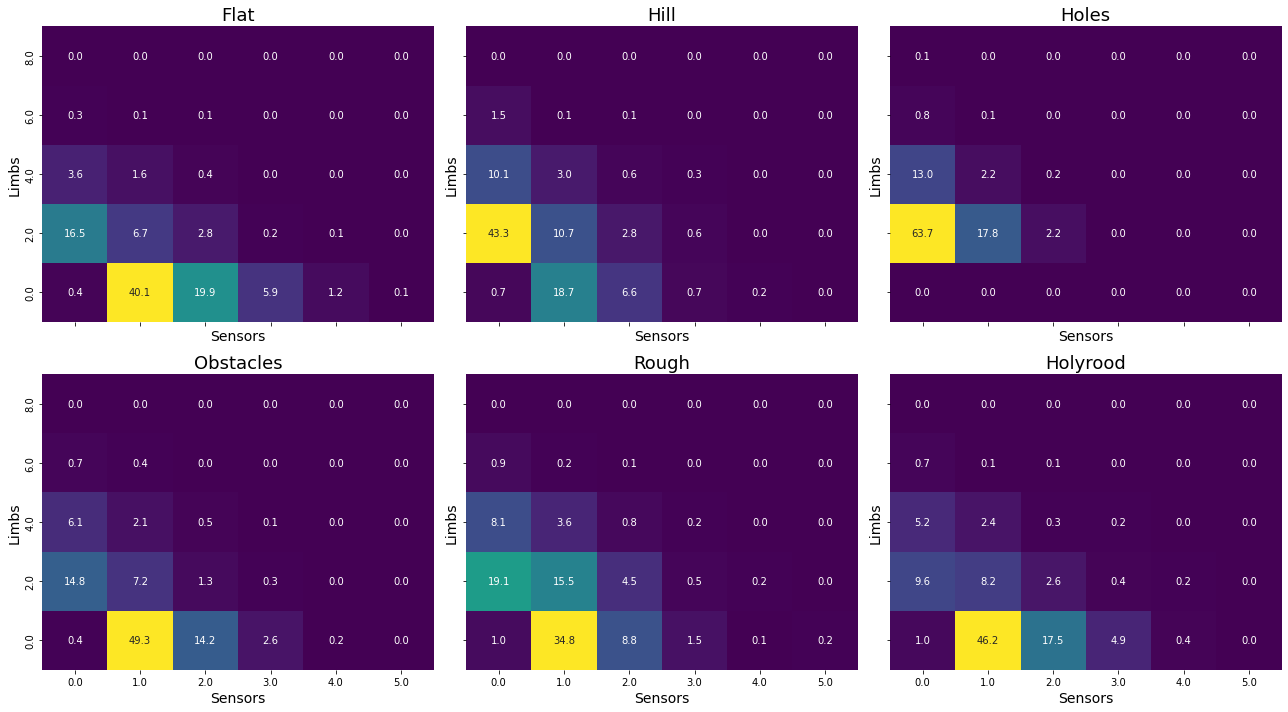

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for idx, env in enumerate(experiments["name"]):
    ax = axes[idx // 3, idx % 3]
    data = df_top[df_top["environment"] == env]
    joint_counts = pd.crosstab(data['limbs'], data['sensors'], normalize='all') * 100
    # ensure the heatmap has the same sensor/limb grid for all environments
    sensors_vals = sorted(df_top['sensors'].unique())
    limbs_vals = sorted(df_top['limbs'].unique())
    joint_counts = joint_counts.reindex(index=limbs_vals, columns=sensors_vals, fill_value=0.0)
    sns.heatmap(joint_counts, annot=True, fmt='.1f', cmap='viridis',
                xticklabels=True, yticklabels=True, cbar=False, ax=ax)
    
    ax.set_title(experiments["print_name"][idx], fontsize=18)
    ax.set_xlabel('Sensors', fontsize=14)
    ax.set_ylabel('Limbs', fontsize=14)
    ax.invert_yaxis()
    # ax.set_xticks(np.arange(0.5, 6.5, 1))
    # ax.set_yticks(np.arange(0.5, 6.5, 1))
    # ax.set_xticklabels(range(6), fontsize=12)
    # ax.set_yticklabels(range(6), fontsize=12)
plt.tight_layout()

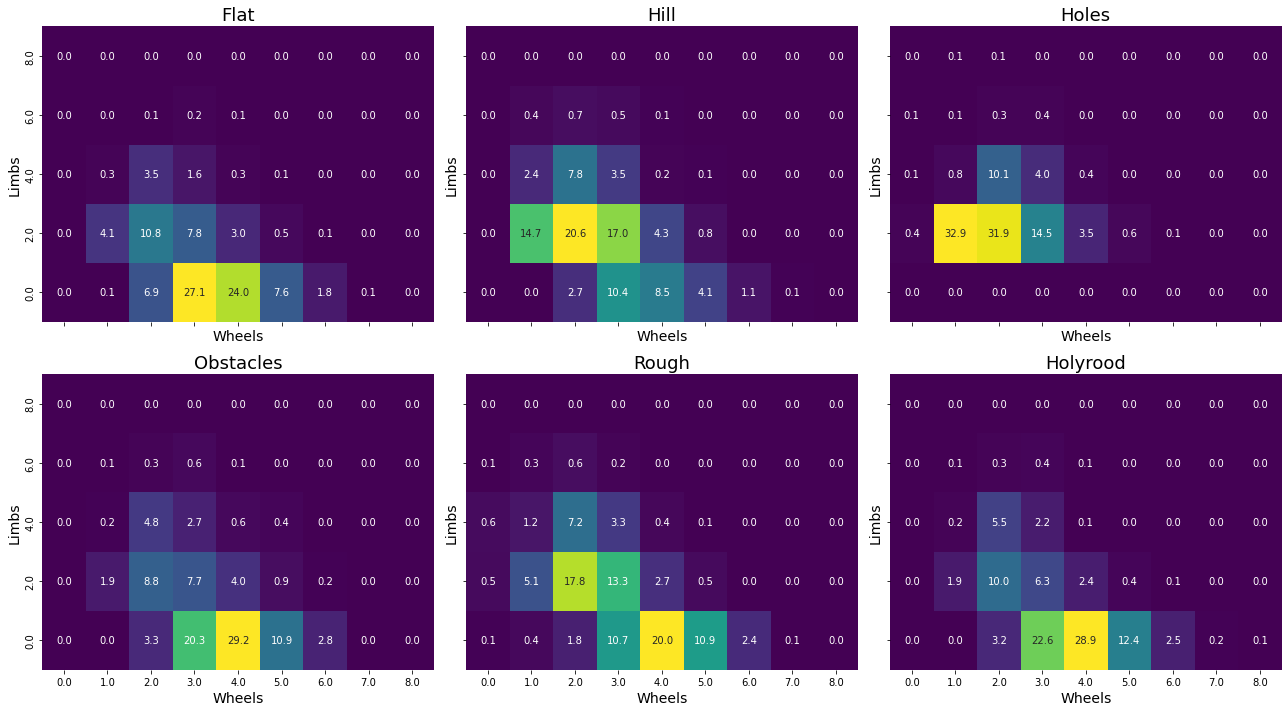

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for idx, env in enumerate(experiments["name"]):
    ax = axes[idx // 3, idx % 3]
    data = df_top[df_top["environment"] == env]
    joint_counts = pd.crosstab(data['limbs'], data['wheels'], normalize='all') * 100
    # ensure the heatmap has the same sensor/limb grid for all environments
    sensors_vals = sorted(df_top['wheels'].unique())
    limbs_vals = sorted(df_top['limbs'].unique())
    joint_counts = joint_counts.reindex(index=limbs_vals, columns=sensors_vals, fill_value=0.0)
    sns.heatmap(joint_counts, annot=True, fmt='.1f', cmap='viridis',
                xticklabels=True, yticklabels=True, cbar=False, ax=ax)
    
    ax.set_title(experiments["print_name"][idx], fontsize=18)
    ax.set_xlabel('Wheels', fontsize=14)
    ax.set_ylabel('Limbs', fontsize=14)
    ax.invert_yaxis()
    # ax.set_xticks(np.arange(0.5, 6.5, 1))
    # ax.set_yticks(np.arange(0.5, 6.5, 1))
    # ax.set_xticklabels(range(6), fontsize=12)
    # ax.set_yticklabels(range(6), fontsize=12)
plt.tight_layout()

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0, 0.0, '0%'),
  Text(0, 0.2, '20%'),
  Text(0, 0.4, '40%'),
  Text(0, 0.6000000000000001, '60%'),
  Text(0, 0.8, '80%'),
  Text(0, 1.0, '100%')])

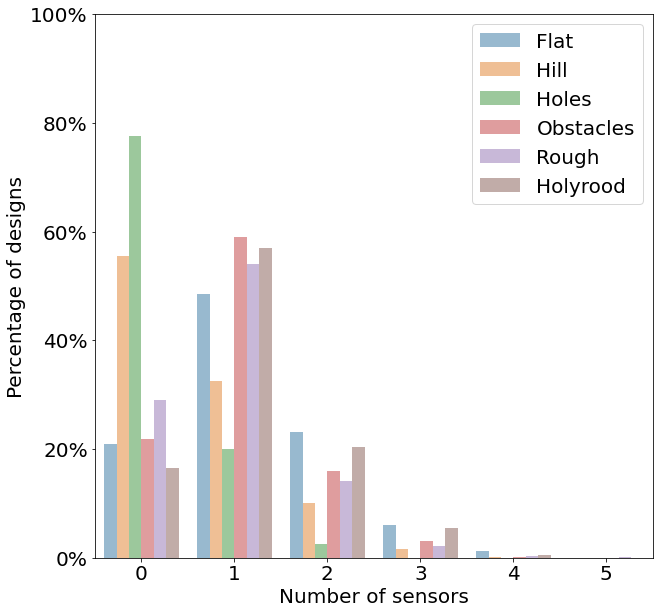

In [18]:
fig = plt.gcf()
fig.set_size_inches(10,10)
df = pd.crosstab(df_top['environment'], df_top['sensors'], normalize='index')
df1 = df.melt(var_name='sensors', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="sensors",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5)
ax.yaxis.label.set_size(20)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_ylim(0,1)
ax.set_xlabel("Number of sensors")
ax.set_ylabel("Percentage of designs")
# ax.set_xlim([-0.5,4.5])
ax.yaxis.label.set_size(20)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=20)

/tmp/ipykernel_354671/1503564937.py:9: UserWarning: Mismatched number of handles and labels: len(handles) = 0 len(labels) = 6
  ax.legend(handles=handles,labels=experiments["print_name"],fontsize=20)
/tmp/ipykernel_354671/1503564937.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles=handles,labels=experiments["print_name"],fontsize=20)


(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0, 0.0, '0%'),
  Text(0, 0.2, '20%'),
  Text(0, 0.4, '40%'),
  Text(0, 0.6000000000000001, '60%'),
  Text(0, 0.8, '80%'),
  Text(0, 1.0, '100%')])

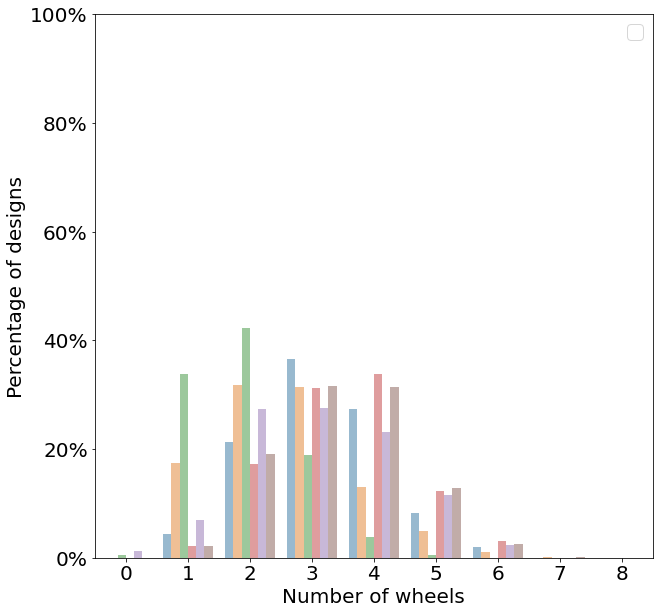

In [19]:
fig = plt.gcf()
fig.set_size_inches(10,10)
df = pd.crosstab(df_top['environment'], df_top['wheels'], normalize='index')
df1 = df.melt(var_name='wheels', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="wheels",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5,legend=False)
ax.yaxis.label.set_size(20)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_ylim(0,1)
ax.set_xlabel("Number of wheels")
ax.set_ylabel("Percentage of designs")
ax.yaxis.label.set_size(20)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=20)

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0, 0.0, '0%'),
  Text(0, 0.2, '20%'),
  Text(0, 0.4, '40%'),
  Text(0, 0.6000000000000001, '60%'),
  Text(0, 0.8, '80%'),
  Text(0, 1.0, '100%')])

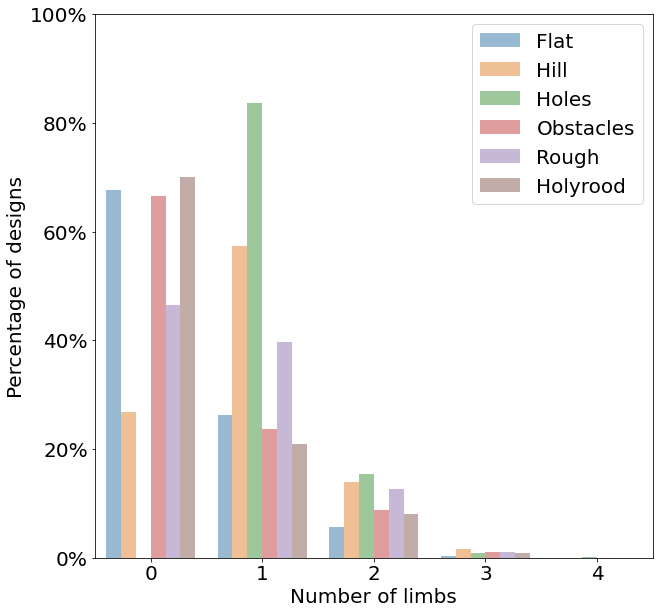

In [20]:
fig = plt.gcf()
fig.set_size_inches(10,10)
df = pd.crosstab(df_top['environment'], df_top['limbs'], normalize='index')
df1 = df.melt(var_name='limbs', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="limbs",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5)
ax.yaxis.label.set_size(20)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_ylim(0,1)
ax.set_xlabel("Number of limbs")
ax.set_ylabel("Percentage of designs")
ax.yaxis.label.set_size(20)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=20)

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0, 0.0, '0%'),
  Text(0, 0.2, '20%'),
  Text(0, 0.4, '40%'),
  Text(0, 0.6000000000000001, '60%'),
  Text(0, 0.8, '80%'),
  Text(0, 1.0, '100%')])

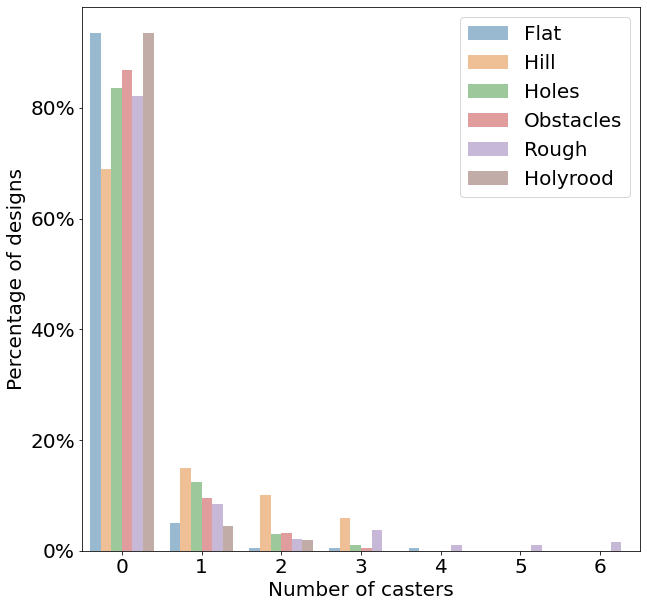

In [21]:
fig = plt.gcf()
fig.set_size_inches(10,10)
df = pd.crosstab(df_top_desc_data['environment'], df_top_desc_data['casters'], normalize='index')
df1 = df.melt(var_name='limbs', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="limbs",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5)
ax.yaxis.label.set_size(20)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Number of casters")
ax.set_ylabel("Percentage of designs")
ax.yaxis.label.set_size(20)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=20)

<Figure size 1440x360 with 0 Axes>

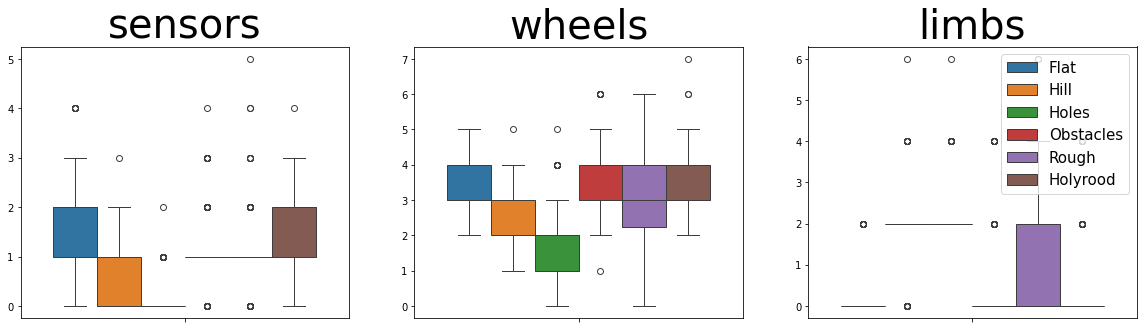

In [65]:
fig = plt.gcf()
fig.set_size_inches(20,5)
plt.figure(figsize=(20,5))
variables = ["sensors", "wheels", "limbs"]#,"casters"]
for i, c in enumerate(variables, 1):
    plt.subplot(1,3,i)
    is_legend = False
    if i == 3:
        is_legend = True
    sns.boxplot(y=c, hue="environment", data=df_top_desc_data, legend=is_legend)
    if i == 3:
      plt.legend(loc='upper right', fontsize=15, labels=experiments["print_name"])
    plt.title(c, fontsize=40)
    plt.ylabel("")
    #plt.suptitle("Top " + str(top_percent) + "%", fontsize=32)
#plt.savefig("img_alife25/high_coverage_diversity_" + str(top_percent) + ".png", bbox_inches='tight')
plt.savefig("img_alife25/features_top1_fitness.png")

In [66]:
# Window of 10% ordered by fitness
windows = 10
window_size = []
for idx, exp in enumerate(experiments["name"]):
    window_size.append(int(desc_data[desc_data.environment.isin([exp])].shape[0] / windows))
feats = ["wheels", "sensors", "limbs"]
wheels = []
sensors = []
limbs = []
full_data = []
for window in range(windows):
    temp = []
    for idx, exp in enumerate(experiments["name"]):
        temp = desc_data[desc_data.environment.isin([exp])].sort_values(by=['fitness'], ascending=True)[window_size[idx] * window : window_size[idx] * (window + 1)]
        temp["window"] = window
        full_data.append(temp)
        # wheels.append([temp.wheels.mean(), temp.wheels.std(), temp.wheels.median(), temp.wheels.mode()[0], temp.wheels.quantile(0.75) - temp.wheels.quantile(0.25), temp.wheels.var(), window, exp, "wheels"])
        # sensors.append([temp.sensors.mean(), temp.sensors.std(), temp.sensors.median(), temp.sensors.mode()[0], temp.sensors.quantile(0.75) - temp.sensors.quantile(0.25), temp.sensors.var(), window, exp, "sensors"])
        # limbs.append([temp.limbs.mean(), temp.limbs.std(), temp.limbs.median(), temp.limbs.mode()[0], temp.limbs.quantile(0.75) - temp.limbs.quantile(0.25), temp.limbs.var(), window, exp, "limbs"])

wheels = pd.DataFrame(data=wheels, columns=["mean", "std", "median", "mode", "IQR", "var",  "window", "environment", "feature"])
sensors = pd.DataFrame(data=sensors, columns=["mean", "std", "median", "mode", "IQR", "var",  "window", "environment", "feature"])
limbs = pd.DataFrame(data=limbs, columns=["mean", "std", "median", "mode", "IQR", "var",  "window", "environment", "feature"])
windowed_data_fitness = pd.concat(full_data).reset_index(drop=True)#pd.concat([wheels, sensors, limbs]).reset_index(drop=True)
#windowed_data = pd.DataFrame(data=windowed_data, columns=["mean", "window", "environment", "feature"])
#print(windowed_data)

<Figure size 576x1440 with 0 Axes>

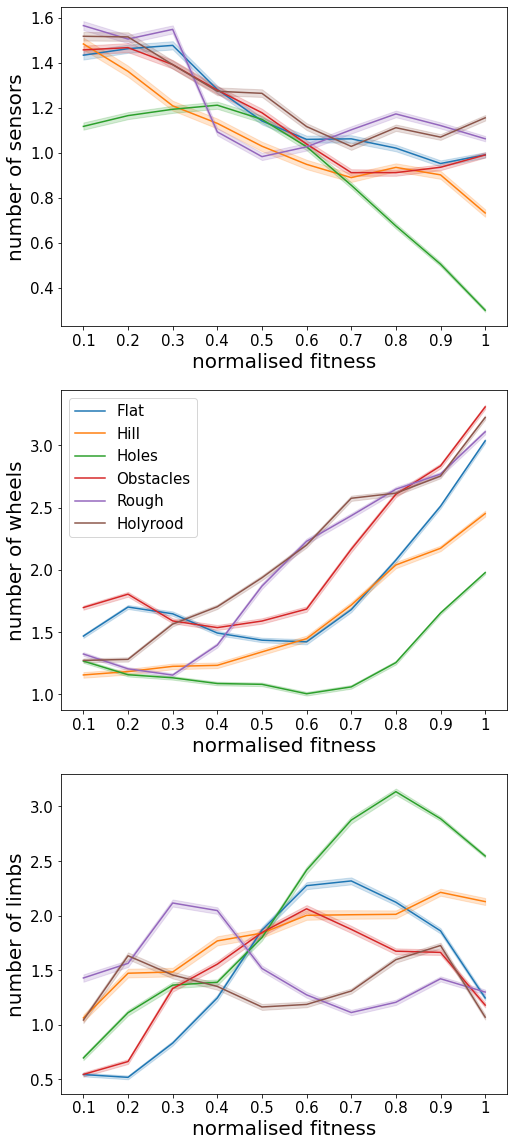

In [67]:
fig = plt.gcf()
fig.set_size_inches(8,20)
plt.figure(figsize=(8,20))
variables = [ "sensors", "wheels", "limbs"]#,"casters"]
for i, c in enumerate(variables, 1):
    plt.subplot(3,1,i)
    is_legend = False
    if i == 2:
        is_legend = True
    ax = sns.lineplot(data=windowed_data_fitness, x="window", y=c, hue="environment", legend=is_legend)
    if(is_legend):
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles=handles,loc='upper left', fontsize=15, labels=experiments["print_name"],title="")
    # plt.title(c, fontsize=20)
    plt.ylabel(f"number of {c}",fontsize=20)
    plt.xlabel("normalised fitness",fontsize=20)
    plt.xlim(-0.5, 9.5)
    plt.xticks([0,1,2,3,4,5,6,7,8,9], ['0.1','0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '1'],fontsize=15)
    plt.yticks(fontsize=15)


    #plt.suptitle("Top " + str(top_percent) + "%", fontsize=32)
plt.savefig("img_alife25/features_trend_fitness.png", bbox_inches='tight')

<Figure size 2160x360 with 0 Axes>

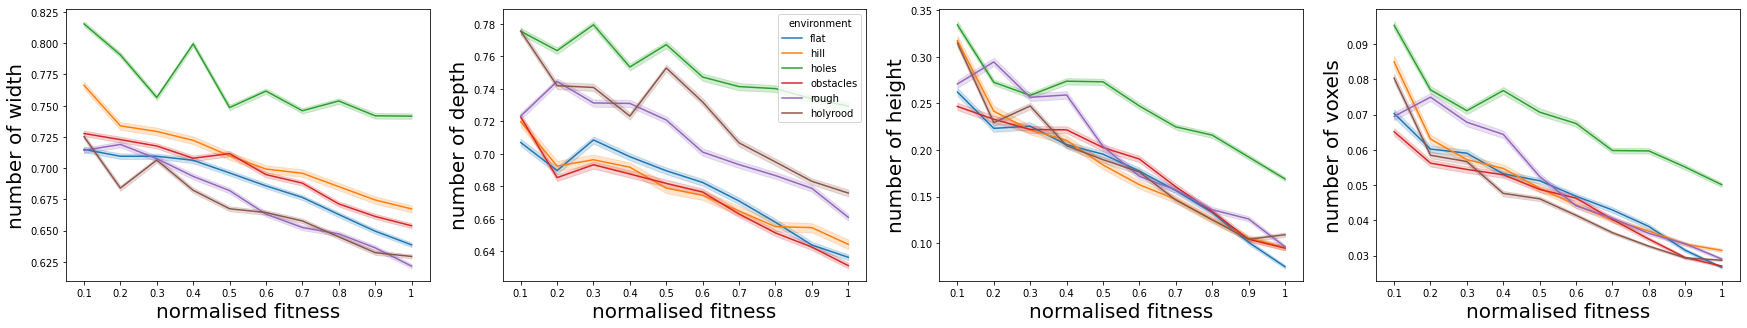

In [68]:
fig = plt.gcf()
fig.set_size_inches(30,5)
plt.figure(figsize=(30,5))
variables = [ "width", "depth", "height", "voxels"]#,"casters"]
for i, c in enumerate(variables, 1):
    plt.subplot(1,4,i)
    is_legend = False
    if i == 2:
        is_legend = True
        plt.legend(loc='upper left', fontsize=15, labels=experiments["print_name"])
    #ax = sns.lineplot(data=windowed_data_fitness[windowed_data_fitness["feature"] == c], x="window", y="mean", hue="environment", legend=is_legend)
    ax = sns.lineplot(data=windowed_data_fitness, x="window", y=c, hue="environment", legend=is_legend)
    plt.ylabel(f"number of {c}",fontsize=20)
    plt.xlabel("normalised fitness",fontsize=20)
    plt.xlim(-0.5, 9.5)
    plt.xticks([0,1,2,3,4,5,6,7,8,9], ['0.1','0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '1'])

    #plt.suptitle("Top " + str(top_percent) + "%", fontsize=32)
plt.savefig("img_alife25/features_trend_fitness.png", bbox_inches='tight')
plt.savefig("img_alife25/features_trend_fitness.png", bbox_inches='tight')

In [69]:
# Window of 10% ordered by replicate index
windows = 10
window_size = []
for idx, exp in enumerate(experiments["name"]):
    window_size.append(int(desc_data[desc_data.environment.isin([exp])].shape[0] / windows))
feats = ["wheels", "sensors", "limbs"]
wheels = []
sensors = []
limbs = []
full_data = []
for window in range(windows):
    temp = []
    for idx, exp in enumerate(experiments["name"]):
        temp = desc_data[desc_data.environment.isin([exp])].sort_values(by=['replicate_index'], ascending=True)[window_size[idx] * window : window_size[idx] * (window + 1)]
        temp["window"] = window
        full_data.append(temp)
        wheels.append([temp.wheels.mean(), temp.wheels.std(), temp.wheels.median(), temp.wheels.mode()[0], temp.wheels.quantile(0.75) - temp.wheels.quantile(0.25), temp.wheels.var(), window, exp, "wheels"])
        sensors.append([temp.sensors.mean(), temp.sensors.std(), temp.sensors.median(), temp.sensors.mode()[0], temp.sensors.quantile(0.75) - temp.sensors.quantile(0.25), temp.sensors.var(), window, exp, "sensors"])
        limbs.append([temp.limbs.mean(), temp.limbs.std(), temp.limbs.median(), temp.limbs.mode()[0], temp.limbs.quantile(0.75) - temp.limbs.quantile(0.25), temp.limbs.var(), window, exp, "limbs"])

wheels = pd.DataFrame(data=wheels, columns=["mean", "std", "median", "mode", "IQR", "var",  "window", "environment", "feature"])
sensors = pd.DataFrame(data=sensors, columns=["mean", "std", "median", "mode", "IQR", "var",  "window", "environment", "feature"])
limbs = pd.DataFrame(data=limbs, columns=["mean", "std", "median", "mode", "IQR", "var",  "window", "environment", "feature"])
windowed_data_generation = pd.concat(full_data).reset_index(drop=True) #pd.concat([wheels, sensors, limbs]).reset_index(drop=True)

#windowed_data = pd.DataFrame(data=windowed_data, columns=["mean", "window", "environment", "feature"])
#print(windowed_data)

<Figure size 576x1440 with 0 Axes>

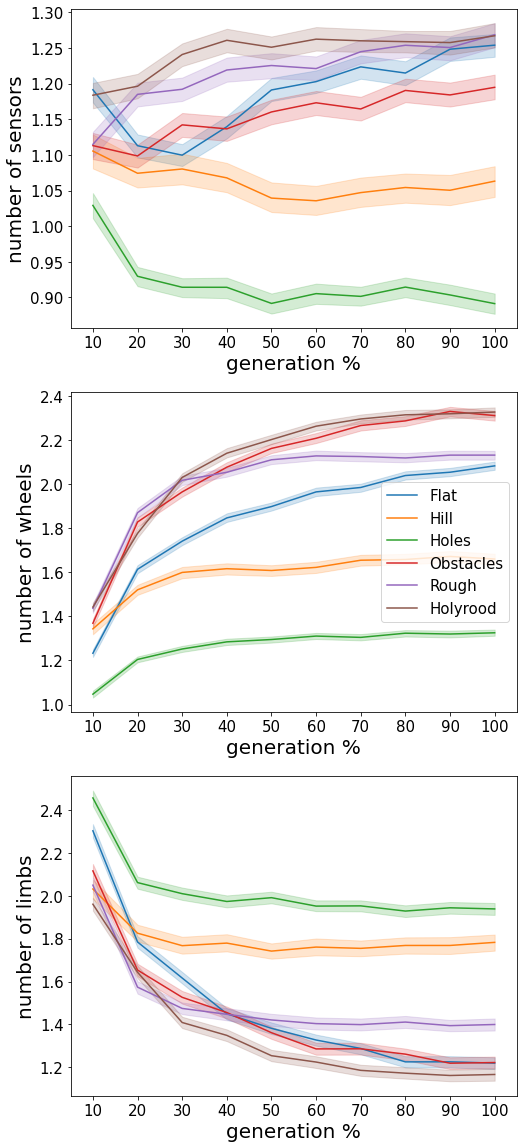

In [70]:
fig = plt.gcf()
fig.set_size_inches(8,20)
plt.figure(figsize=(8,20))
variables = [ "sensors", "wheels", "limbs"]#,"casters"]
for i, c in enumerate(variables, 1):
    plt.subplot(3,1,i)
    is_legend = False
    if i == 2:
        is_legend = True
    #ax = sns.scatterplot(data=windowed_data_generation[windowed_data_generation["feature"] == c], x="window", y="mean", hue="environment", legend=is_legend)
    ax = sns.lineplot(data=windowed_data_generation, x="window", y=c, hue="environment", legend=is_legend)
    if(is_legend):
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles=handles,loc='center right', fontsize=15, labels=experiments["print_name"],title="")
    #plt.legend(loc='upper left', fontsize=15, labels=experiments["print_name"])
    #ax.errorbar(windowed_data[windowed_data["feature"] == c]["window"], windowed_data[windowed_data["feature"] == c]["mean"], yerr= windowed_data[windowed_data["feature"] == c]["std"],fmt='o')
    
    plt.ylabel(f"number of {c}",fontsize=20)
    plt.xlabel("generation %",fontsize=20)
    plt.xlim(-0.5, 9.5)
    plt.xticks([0,1,2,3,4,5,6,7,8,9], ['10','20', '30', '40', '50', '60', '70', '80', '90', '100'],fontsize=15)
    plt.yticks(fontsize=15)

    #plt.suptitle("Top " + str(top_percent) + "%", fontsize=32)
plt.savefig("img_alife25/features_trend_generation.png", bbox_inches='tight')

<Figure size 2160x360 with 0 Axes>

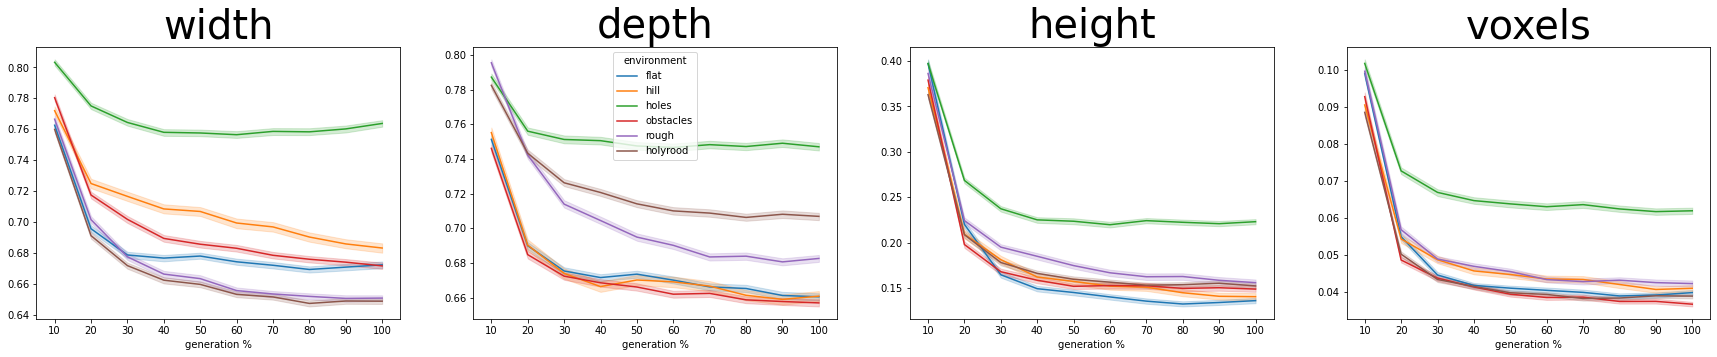

In [71]:
fig = plt.gcf()
fig.set_size_inches(30,5)
plt.figure(figsize=(30,5))
variables = [ "width", "depth", "height", "voxels"]#,"casters"]
for i, c in enumerate(variables, 1):
    plt.subplot(1,4,i)
    is_legend = False
    if i == 2:
        is_legend = True
        plt.legend(loc='upper left', fontsize=15, labels=experiments["print_name"])
    #ax = sns.scatterplot(data=windowed_data_generation[windowed_data_generation["feature"] == c], x="window", y="mean", hue="environment", legend=is_legend)
    ax = sns.lineplot(data=windowed_data_generation, x="window", y=c, hue="environment", legend=is_legend)
    #plt.legend(loc='upper left', fontsize=15, labels=experiments["print_name"])
    #ax.errorbar(windowed_data[windowed_data["feature"] == c]["window"], windowed_data[windowed_data["feature"] == c]["mean"], yerr= windowed_data[windowed_data["feature"] == c]["std"],fmt='o')
    
    plt.title(c, fontsize=40)
    plt.ylabel("")
    plt.xlabel("generation %")
    plt.xlim(-0.5, 9.5)
    plt.xticks([0,1,2,3,4,5,6,7,8,9], ['10','20', '30', '40', '50', '60', '70', '80', '90', '100'])

    #plt.suptitle("Top " + str(top_percent) + "%", fontsize=32)
# plt.savefig("img_alife25/features_trend_generation.png", bbox_inches='tight')

In [72]:
windowed_data

NameError: name 'windowed_data' is not defined

(array([0.  , 0.25, 0.5 , 0.75, 1.  , 1.25, 1.5 , 1.75, 2.  ]),
 [Text(0, 0.0, '0.00'),
  Text(0, 0.25, '0.25'),
  Text(0, 0.5, '0.50'),
  Text(0, 0.75, '0.75'),
  Text(0, 1.0, '1.00'),
  Text(0, 1.25, '1.25'),
  Text(0, 1.5, '1.50'),
  Text(0, 1.75, '1.75'),
  Text(0, 2.0, '2.00')])

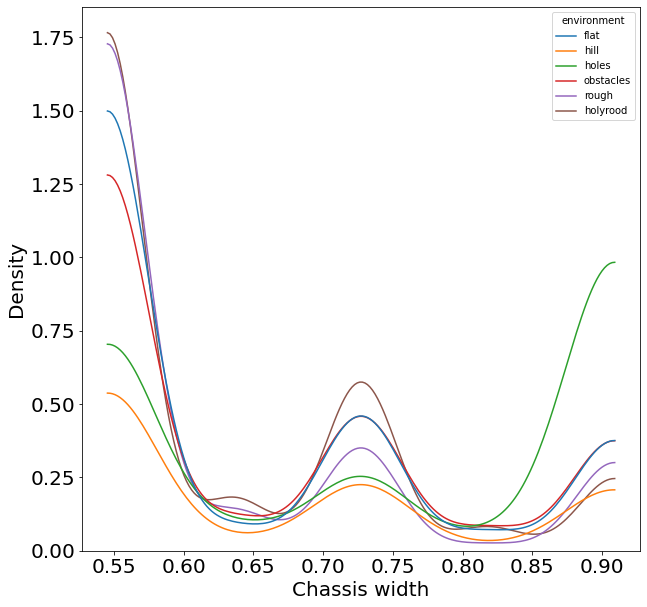

In [39]:
fig = plt.gcf()
fig.set_size_inches(10,10)
ax = sns.kdeplot(data=df_top,x="width",hue="environment",cut=0,hue_order=experiments["name"])
ax.yaxis.label.set_size(20)
#plt.legend(["flat","terrain 1","terrain 2","terrain 3"],fontsize=20,loc=2)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Chassis width")
ax.yaxis.label.set_size(20)
plt.yticks(fontsize=20)

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6]),
 [Text(0, 0.0, '0.0'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.4, '0.4'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.8, '0.8'),
  Text(0, 1.0, '1.0'),
  Text(0, 1.2000000000000002, '1.2'),
  Text(0, 1.4000000000000001, '1.4'),
  Text(0, 1.6, '1.6')])

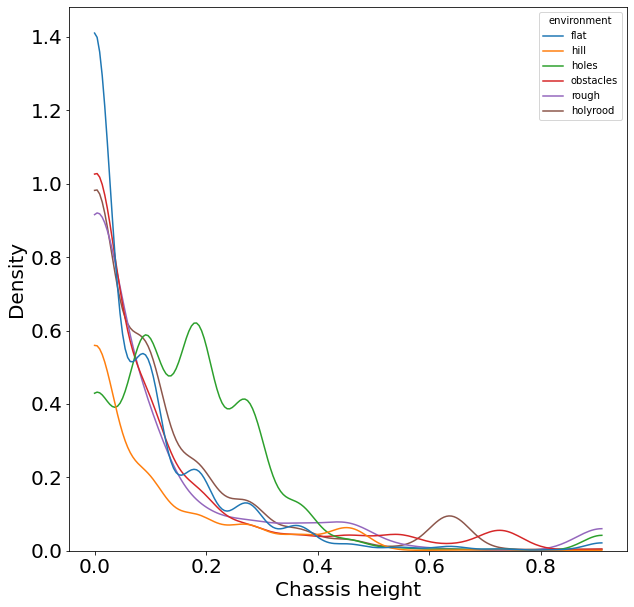

In [40]:
fig = plt.gcf()
fig.set_size_inches(10,10)
ax = sns.kdeplot(data=df_top,x="height",hue="environment",cut=0)
ax.yaxis.label.set_size(20)
#plt.legend(["flat","terrain 1","terrain 2","terrain 3"],fontsize=20,loc=2)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Chassis height")
ax.yaxis.label.set_size(20)
plt.yticks(fontsize=20)

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8]),
 [Text(0, 0.0, '0.0'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.4, '0.4'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.8, '0.8'),
  Text(0, 1.0, '1.0'),
  Text(0, 1.2000000000000002, '1.2'),
  Text(0, 1.4000000000000001, '1.4'),
  Text(0, 1.6, '1.6'),
  Text(0, 1.8, '1.8')])

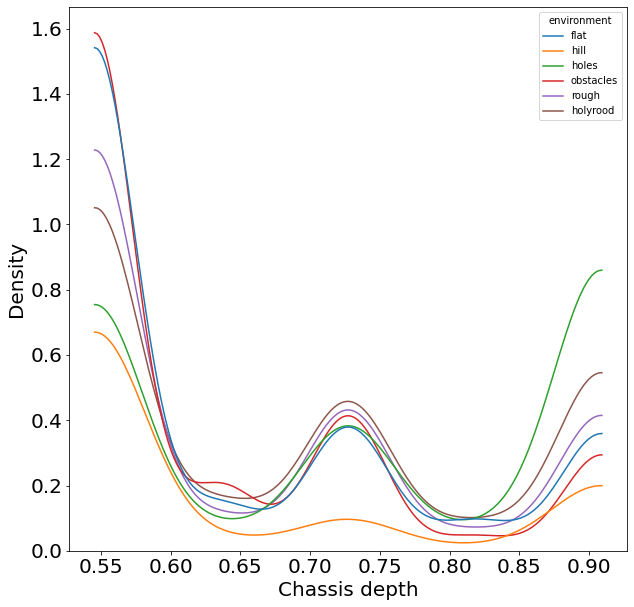

In [41]:
fig = plt.gcf()
fig.set_size_inches(10,10)
ax = sns.kdeplot(data=df_top,x="depth",hue="environment",cut=0)
ax.yaxis.label.set_size(20)
#plt.legend(["flat","terrain 1","terrain 2","terrain 3"],fontsize=20,loc=2)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Chassis depth")
ax.yaxis.label.set_size(20)
plt.yticks(fontsize=20)

(array([ 0.,  2.,  4.,  6.,  8., 10., 12., 14.]),
 [Text(0, 0.0, '0'),
  Text(0, 2.0, '2'),
  Text(0, 4.0, '4'),
  Text(0, 6.0, '6'),
  Text(0, 8.0, '8'),
  Text(0, 10.0, '10'),
  Text(0, 12.0, '12'),
  Text(0, 14.0, '14')])

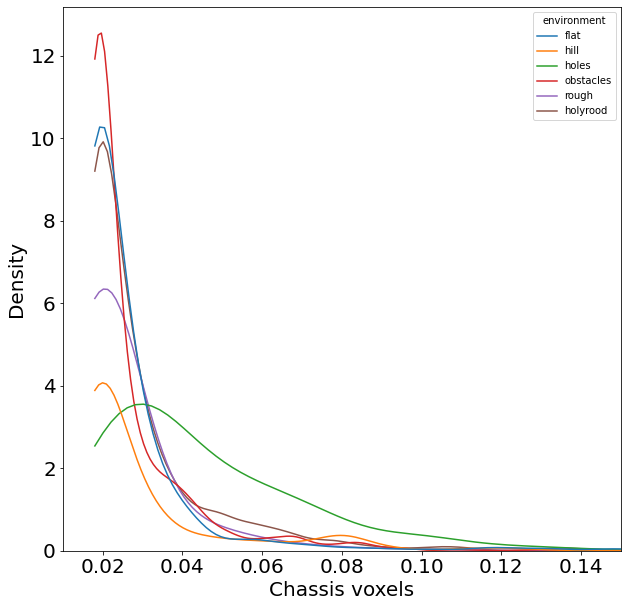

In [42]:
fig = plt.gcf()
fig.set_size_inches(10,10)
ax = sns.kdeplot(data=df_top,x="voxels",hue="environment",cut=0)
ax.yaxis.label.set_size(20)
#plt.legend(["flat","terrain 1","terrain 2","terrain 3"],fontsize=20,loc=2)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlim(0.01,0.15)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Chassis voxels")
ax.yaxis.label.set_size(20)
plt.yticks(fontsize=20)

## Chassis diversity

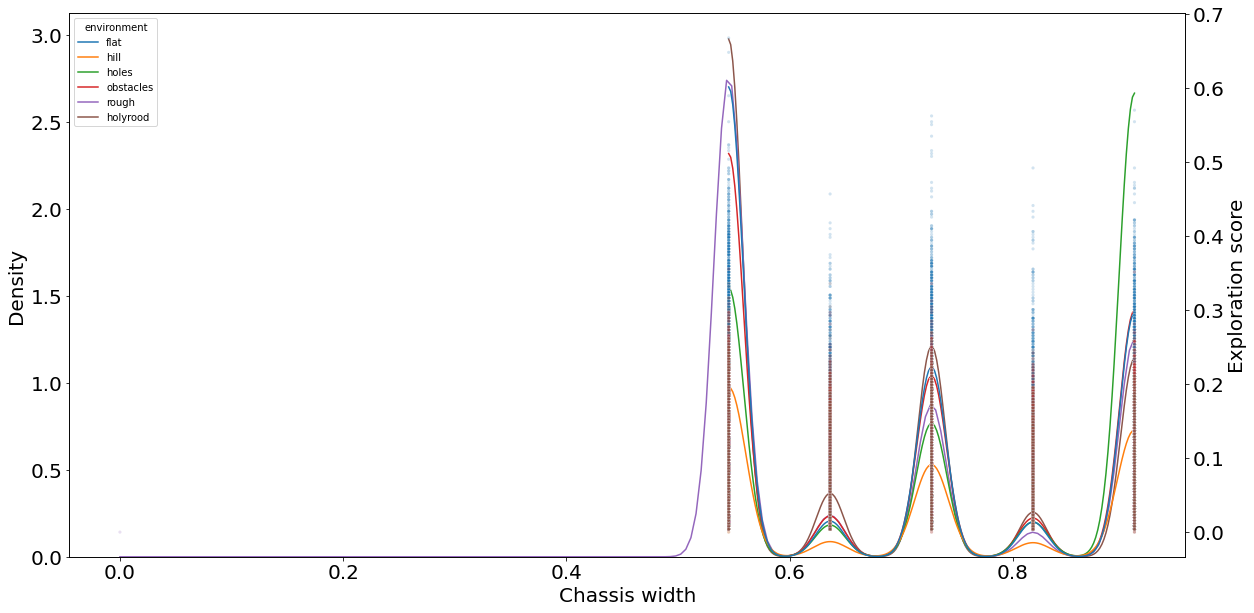

In [73]:
fig = plt.gcf()
fig.set_size_inches(20,10)
ax = sns.kdeplot(data=desc_data,x="width",hue="environment",cut=0,hue_order=experiments["name"])
ax.yaxis.label.set_size(20)
#plt.legend(["flat","terrain 1","terrain 2","terrain 3"],fontsize=20,loc=2)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Chassis width")
ax = plt.twinx()
sns.scatterplot(data=desc_data,x="width",y="fitness",hue="environment",ax=ax,s=10,legend=False,alpha=0.2,hue_order=experiments["name"])
ax.set_ylabel("Coverage")
ax.set_ylabel("Exploration score")
ax.yaxis.label.set_size(20)
plt.yticks(fontsize=20)
plt.savefig("img_alife25/distribution_chassis_width.png", bbox_inches='tight')

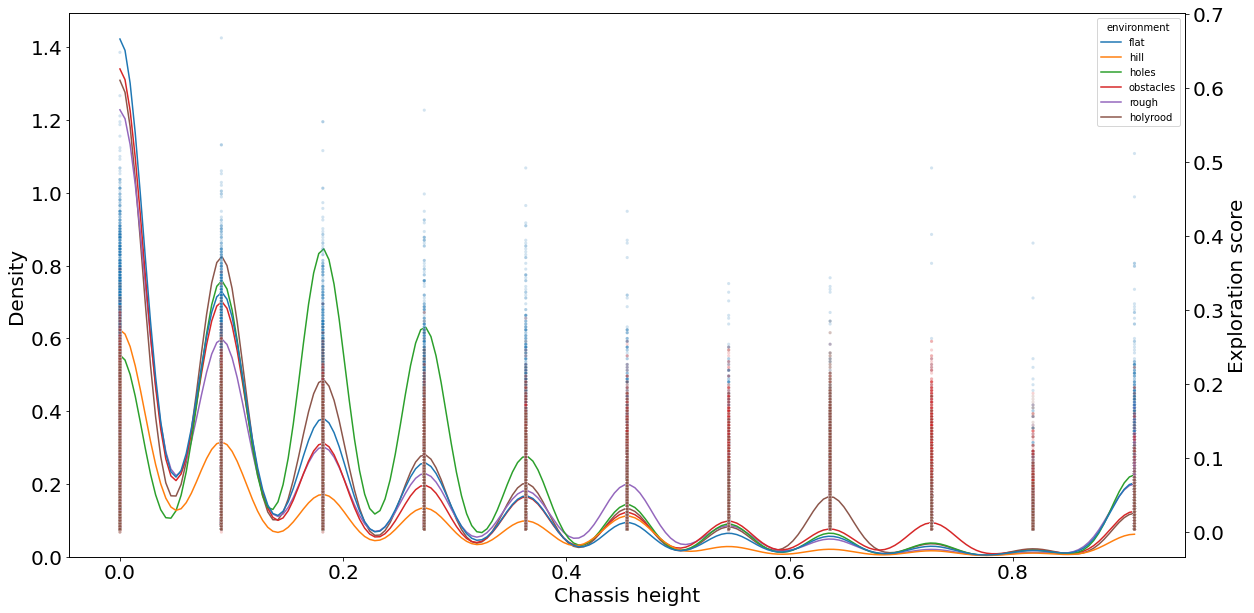

In [74]:
fig = plt.gcf()
fig.set_size_inches(20,10)
ax = sns.kdeplot(data=desc_data,x="height",hue="environment",cut=0)
ax.yaxis.label.set_size(20)
#plt.legend(["flat","terrain 1","terrain 2","terrain 3"],fontsize=20,loc=2)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Chassis height")
ax = plt.twinx()
sns.scatterplot(data=desc_data,x="height",y="fitness",hue="environment",ax=ax,s=10,legend=False,alpha=0.2)
ax.set_ylabel("Exploration score")
ax.yaxis.label.set_size(20)
plt.yticks(fontsize=20)
plt.savefig("img_alife25/distribution_chassis_height.png", bbox_inches='tight')

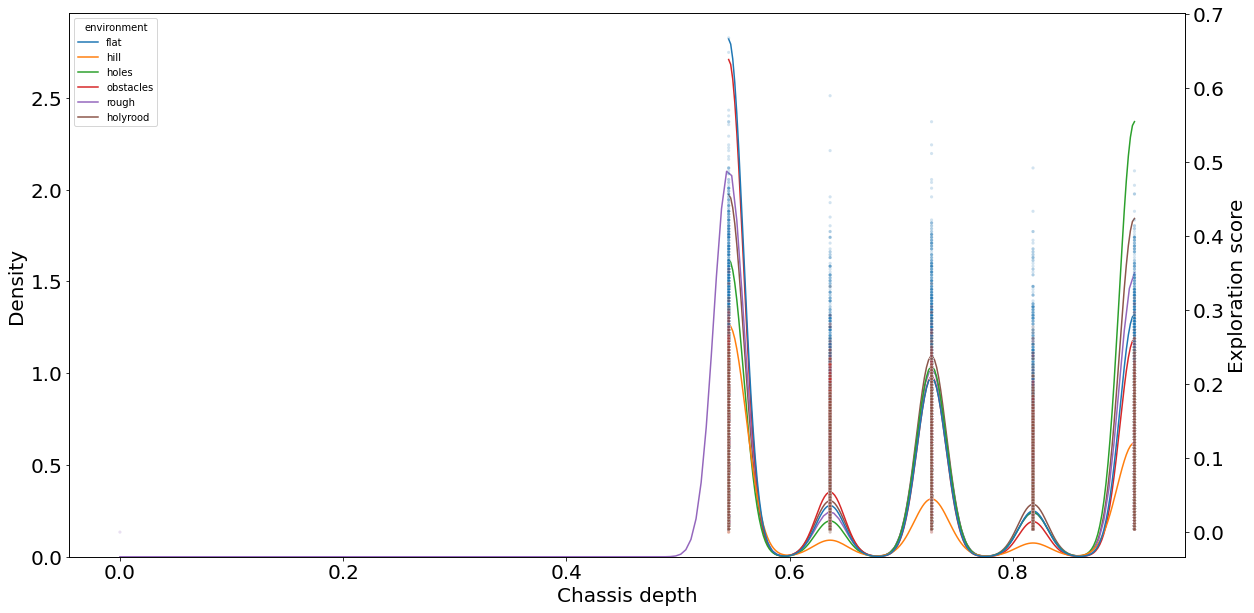

In [75]:
fig = plt.gcf()
fig.set_size_inches(20,10)
ax = sns.kdeplot(data=desc_data,x="depth",hue="environment",cut=0)
ax.yaxis.label.set_size(20)
#plt.legend(["flat","terrain 1","terrain 2","terrain 3"],fontsize=20,loc=2)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Chassis depth")
ax = plt.twinx()
sns.scatterplot(data=desc_data,x="depth",y="fitness",hue="environment",ax=ax,s=10,legend=False,alpha=0.2)
ax.set_ylabel("Exploration score")
ax.yaxis.label.set_size(20)
plt.yticks(fontsize=20)
plt.savefig("img_alife25/distribution_chassis_depth.png", bbox_inches='tight')

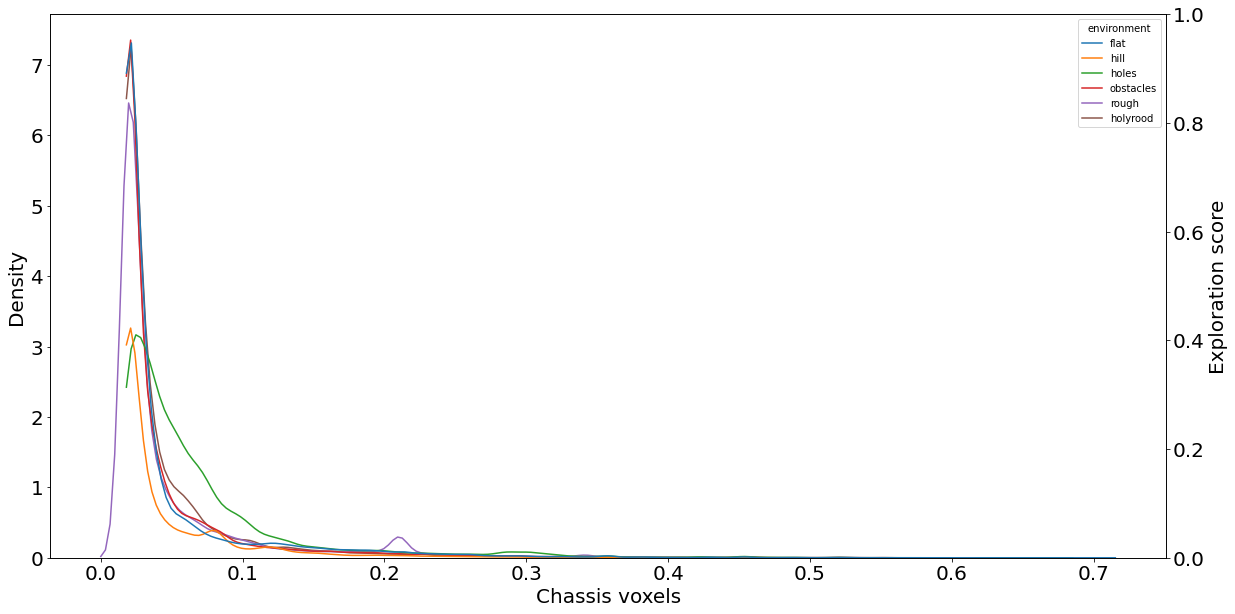

In [76]:
fig = plt.gcf()
fig.set_size_inches(20,10)
sns.scatterplot(data=desc_data,x="voxels",y="fitness",hue="environment",ax=ax,s=10,legend=False,alpha=0.2)
ax = sns.kdeplot(data=desc_data,x="voxels",hue="environment",cut=0)
ax.yaxis.label.set_size(20)
#plt.legend(["flat","terrain 1","terrain 2","terrain 3"],fontsize=20,loc=2)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Chassis voxels")
ax = plt.twinx()
ax.set_ylabel("Exploration score")
ax.yaxis.label.set_size(20)
plt.yticks(fontsize=20)
plt.savefig("img_alife25/distribution_chassis_voxels.png", bbox_inches='tight')

# DUAL CPPNs

In [28]:
repo_folder = "/media/leni/DATADRIVE1/gecco_2026/"
experiments = {
    "directory" :  ['meim_cppn_flat', 'meim_cppn_hill', 'meim_cppn_cracks', 'meim_cppn_obstacles', 'meim_cppn_rough', 'meim_cppn_holyrood' ],
    "name" :       ['flat', 'hill', 'holes', 'obstacles', 'rough', 'holyrood'],
    "print_name" : ['Flat', 'Hill', 'Holes', 'Obstacles', 'Rough', 'Holyrood'],
}

In [29]:
def load_experiment(name, folders):
    experiments_loaded = 0
    exp_fits = []
    for folder in folders:
        #print(folder)
        ids, parents, fitnesses, evals, deltas, replicate_index = medf.load_fitness(folder + "/fitness.csv")
        eval_times = medf.load_comp_time_dict(folder + "/times.csv")
        fits = [[i, p[0], p[1], eval_times[i][0]/(1000000*3600), eval_times[i][1]/(1000000*3600), f, folder, r] 
                for i, p, f, r in zip(ids,parents,fitnesses, replicate_index)]
        exp_fits += fits
        experiments_loaded += 1
        print(folder, " -- Robots: ", len(ids))
    fit_data = pd.DataFrame(data=exp_fits,columns=[      "robot index",
                                                         "parent 1",
                                                         "parent 2",
                                                         "evaluation time",
                                                         "time",
                                                         "fitness",
                                                         "replicate", 
                                                         "replicate_index"])
    fit_data["environment"] = name
    print("Total experiments loaded: ", experiments_loaded, "-- Total robots: ", len(fit_data))
    return fit_data

In [30]:
def load_morphology(name, folders):
    exp_descs = []
    experiments_loaded = 0
    for folder in folders:
        #parent_ids = medf.load_parent_pool(folder + "/parent_pool.csv")
        descriptors = medf.load_feature_descriptor(folder + "/morph_features.csv")
        #print(descriptors[-1])
        descs = [[int(d[0])] + d[1:5] + [d[5]*16,
                                         d[6]*16,
                                         d[7]*16,
                                         d[8]*16]
                                           + d[9:]  + [folder] 
                 for d in descriptors]
        #print(descs[-1])
        #parent_descs += medf.filter_to_parent_pool(descs,parent_ids)
        exp_descs += descs        
        print(folder, " -- Robots: ", len(descs))
        experiments_loaded += 1
    data = pd.DataFrame(data=exp_descs,columns=[
                                                            "robot index",
                                                            "width",
                                                            "depth",
                                                            "height",
                                                            "voxels",
                                                            "wheels",
                                                            "sensors",
                                                            "limbs",
                                                            "casters",
                                                            "norm",
                                                            "skeleton norm",
                                                            "components norm",
                                                            "replicate_index", 
                                                            "replicate"])
    data["environment"] = name
    print("Total experiments loaded: ", experiments_loaded, "-- Total robots: ", len(data))
    return data

In [31]:
# Load fitness data
robot_data = []
for idx, exps in enumerate(experiments['directory']):
    print(exps)
    folders = []
    data = []
    for folder in os.listdir(repo_folder + exps):
            folders.append(repo_folder + exps + '/' + folder)
    data = load_experiment(experiments['name'][idx], folders)
    robot_data.append(data)


meim_cppn_flat
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_flat/meim_cppn_flat_10_9_11-22-53-3739-2609065298  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_flat/meim_cppn_flat_14_9_23-31-19-9024-811798372  -- Robots:  5269
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_flat/meim_cppn_flat_14_9_23-49-18-8162-3642162703  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_flat/meim_cppn_flat_15_9_0-15-50-221-1269457654  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_flat/meim_cppn_flat_15_9_0-4-45-5172-3415429603  -- Robots:  10054
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_flat/meim_cppn_flat_15_9_9-41-18-8444-4163760156  -- Robots:  9047
Total experiments loaded:  6 -- Total robots:  54370
meim_cppn_hill
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_hill/meim_cppn_hill_10_9_11-22-3-3695-1244184029  -- Robots:  4839
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_hill/meim_cppn_hill_10_9_11-26-48-8419-4233249506  -- Robots:  10001
/media/leni/DATADRIVE1/

In [32]:
# loading descriptor data
robot_desc_data = []
for idx, exps in enumerate(experiments['directory']):
    print(exps)
    folders = []
    data = []
    for folder in os.listdir(repo_folder + exps):
            folders.append(repo_folder + exps + '/' + folder)
    data = load_morphology(experiments['name'][idx], folders)
    robot_desc_data.append(data)

meim_cppn_flat
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_flat/meim_cppn_flat_10_9_11-22-53-3739-2609065298  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_flat/meim_cppn_flat_14_9_23-31-19-9024-811798372  -- Robots:  5269
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_flat/meim_cppn_flat_14_9_23-49-18-8162-3642162703  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_flat/meim_cppn_flat_15_9_0-15-50-221-1269457654  -- Robots:  10000
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_flat/meim_cppn_flat_15_9_0-4-45-5172-3415429603  -- Robots:  10054
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_flat/meim_cppn_flat_15_9_9-41-18-8444-4163760156  -- Robots:  9047
Total experiments loaded:  6 -- Total robots:  54370
meim_cppn_hill
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_hill/meim_cppn_hill_10_9_11-22-3-3695-1244184029  -- Robots:  4839
/media/leni/DATADRIVE1/gecco_2026/meim_cppn_hill/meim_cppn_hill_10_9_11-26-48-8419-4233249506  -- Robots:  10001
/media/leni/DATADRIVE1/

In [33]:
# Concat all the parents data
fit_data = pd.concat(robot_data).reset_index(drop=True)
#fit_data = fit_data[fit_data["replicate_index"] <= 6000]

# Selecting highest robot per replicate
fit_max_data = []
for env in experiments["name"]:
    tmp_data = fit_data.loc[fit_data["environment"] == env]
    for rep in tmp_data["replicate"].drop_duplicates():
        tmp_data2 = tmp_data.loc[tmp_data["replicate"] == rep]
        fit_max_data.append(pd.DataFrame(tmp_data2.max(numeric_only=True)).transpose())
        fit_max_data[-1]["replicate"] = rep
        fit_max_data[-1]["environment"] = env
            
fit_max_data = pd.concat(fit_max_data)
fit_max_data.index = [i for i in range(len(fit_max_data))]

In [34]:
desc_data = pd.concat(robot_desc_data).reset_index(drop=True)
desc_data = pd.merge(desc_data, fit_data, how="left",
                     on=["robot index", "replicate", "environment", "replicate_index"])
desc_data = desc_data.drop_duplicates(subset=['robot index','replicate'])
#desc_data = desc_data[desc_data["replicate_index"] <= 6000]


## Exploration Score

/tmp/ipykernel_2234792/2931069552.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(experiments["print_name"])


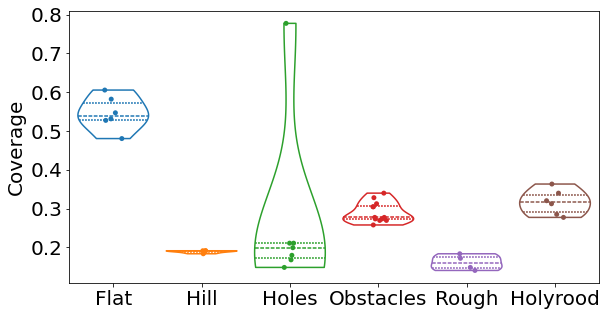

In [ ]:
fig = plt.gcf()
fig.set_size_inches(9.5,5)
ax = sns.violinplot(fit_max_data,x="environment",hue="environment",y="fitness",fill=False,inner="quart", cut=0)
sns.stripplot(fit_max_data,x="environment",hue="environment",y="fitness")
ax.set_xlabel("")
ax.set_xticklabels(experiments["print_name"])
ax.set_ylabel("Coverage")
ax.xaxis.label.set_size(20)
ax.yaxis.label.set_size(20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.savefig("img_alife25/exploration_score.png")


## Components diversity

(array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 ]),
 [Text(0, 0.0, '0%'),
  Text(0, 0.05, '5%'),
  Text(0, 0.1, '10%'),
  Text(0, 0.15000000000000002, '15%'),
  Text(0, 0.2, '20%'),
  Text(0, 0.25, '25%'),
  Text(0, 0.30000000000000004, '30%'),
  Text(0, 0.35000000000000003, '35%'),
  Text(0, 0.4, '40%')])

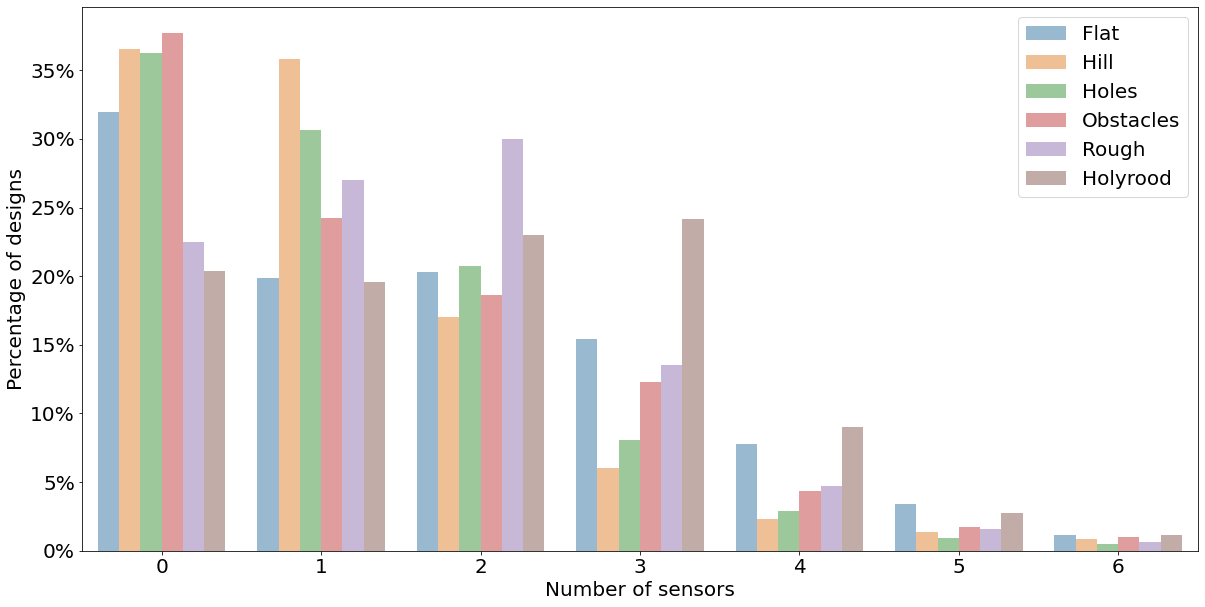

In [24]:
fig = plt.gcf()
fig.set_size_inches(20,10)
df = pd.crosstab(desc_data['environment'], desc_data['sensors'], normalize='index')
df1 = df.melt(var_name='sensors', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="sensors",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5)
ax.yaxis.label.set_size(20)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Number of sensors")
ax.set_ylabel("Percentage of designs")
ax.yaxis.label.set_size(20)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=20)

(array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35]),
 [Text(0, 0.0, '0%'),
  Text(0, 0.05, '5%'),
  Text(0, 0.1, '10%'),
  Text(0, 0.15000000000000002, '15%'),
  Text(0, 0.2, '20%'),
  Text(0, 0.25, '25%'),
  Text(0, 0.30000000000000004, '30%'),
  Text(0, 0.35000000000000003, '35%')])

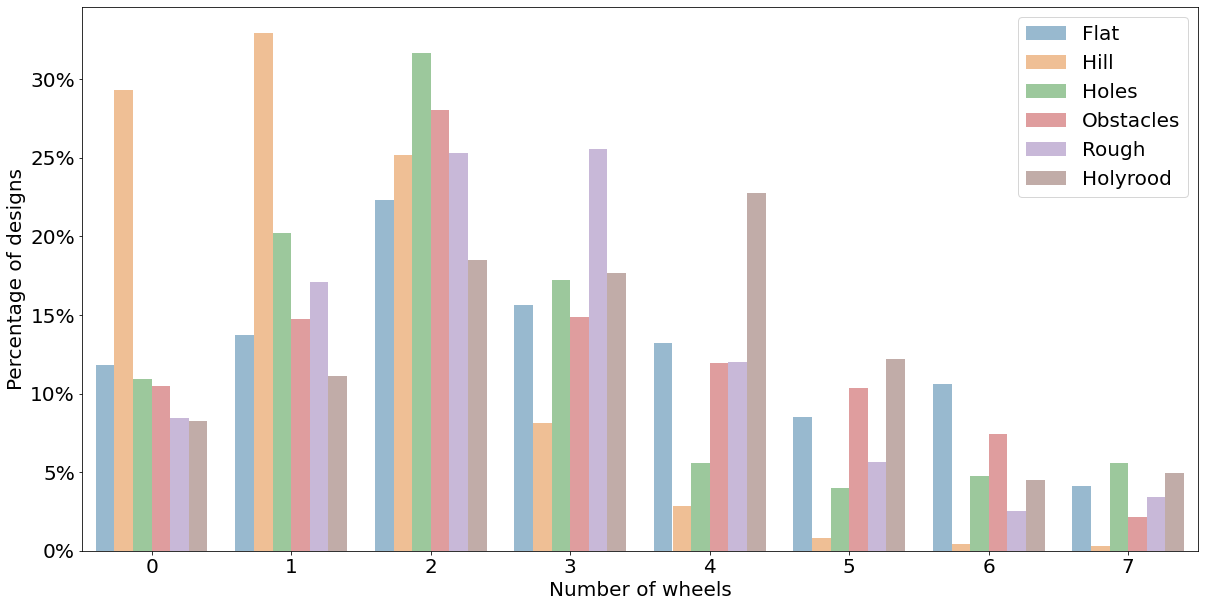

In [25]:
fig = plt.gcf()
fig.set_size_inches(20,10)
df = pd.crosstab(desc_data['environment'], desc_data['wheels'], normalize='index')
df1 = df.melt(var_name='wheels', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="wheels",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5)
ax.yaxis.label.set_size(20)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Number of wheels")
ax.set_ylabel("Percentage of designs")
ax.yaxis.label.set_size(20)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=20)

(array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]),
 [Text(0, 0.0, '0%'),
  Text(0, 0.1, '10%'),
  Text(0, 0.2, '20%'),
  Text(0, 0.30000000000000004, '30%'),
  Text(0, 0.4, '40%'),
  Text(0, 0.5, '50%'),
  Text(0, 0.6000000000000001, '60%'),
  Text(0, 0.7000000000000001, '70%')])

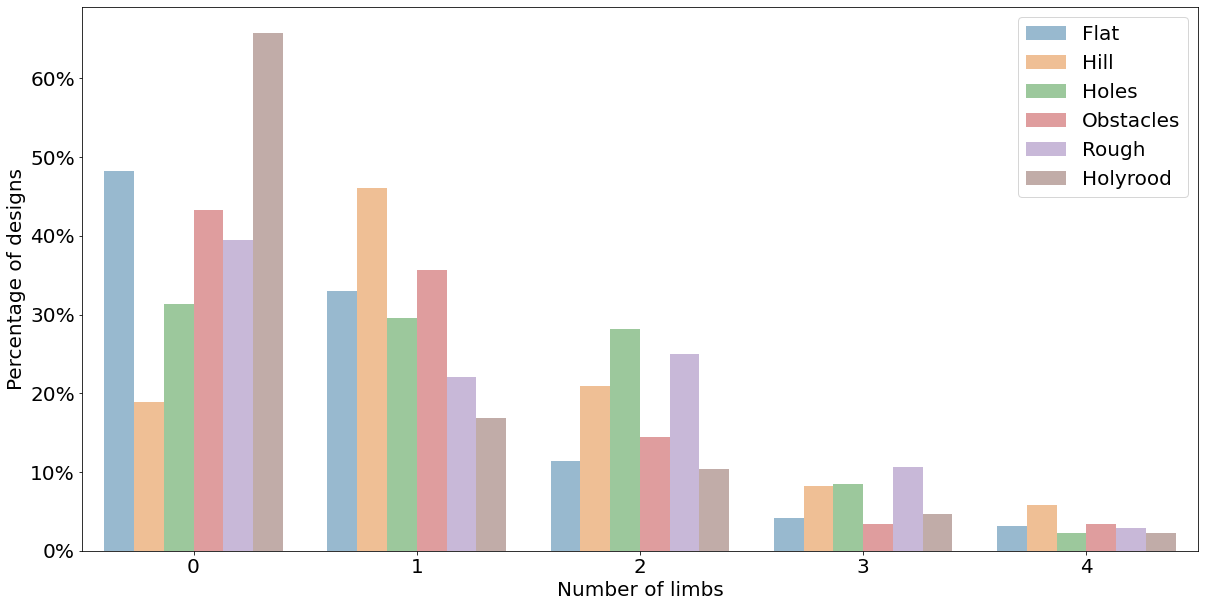

In [26]:
fig = plt.gcf()
fig.set_size_inches(20,10)
df = pd.crosstab(desc_data['environment'], desc_data['limbs'], normalize='index')
df1 = df.melt(var_name='limbs', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="limbs",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5)
ax.yaxis.label.set_size(20)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Number of limbs")
ax.set_ylabel("Percentage of designs")
ax.yaxis.label.set_size(20)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=20)

(array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]),
 [Text(0, 0.0, '0%'),
  Text(0, 0.1, '10%'),
  Text(0, 0.2, '20%'),
  Text(0, 0.30000000000000004, '30%'),
  Text(0, 0.4, '40%'),
  Text(0, 0.5, '50%'),
  Text(0, 0.6000000000000001, '60%'),
  Text(0, 0.7000000000000001, '70%'),
  Text(0, 0.8, '80%'),
  Text(0, 0.9, '90%')])

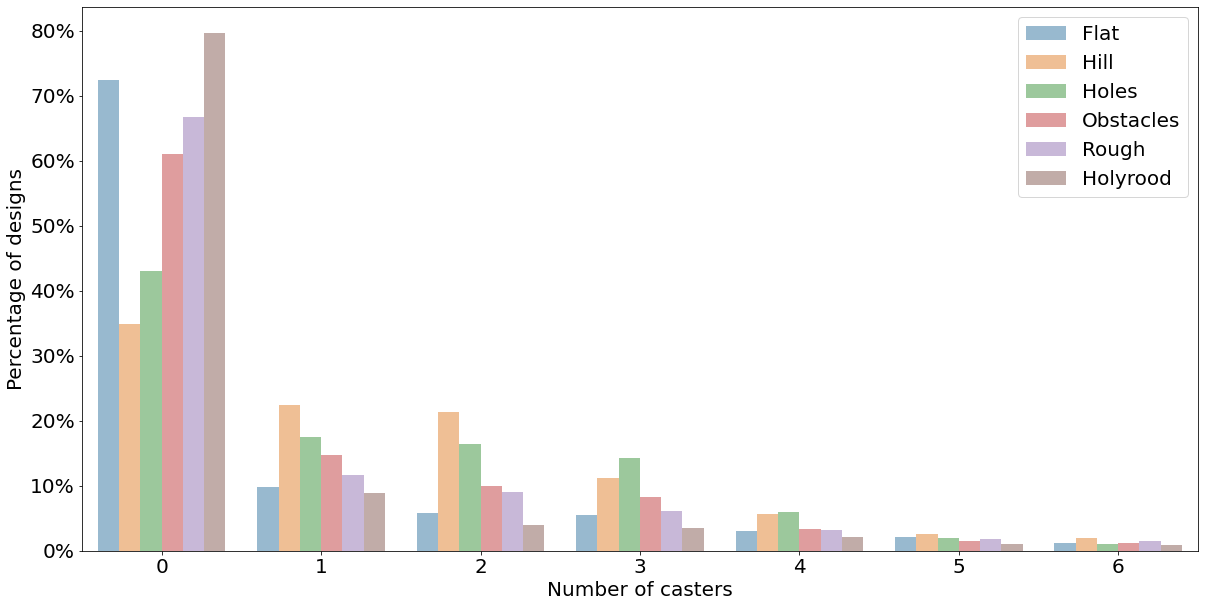

In [27]:
fig = plt.gcf()
fig.set_size_inches(20,10)
df = pd.crosstab(desc_data['environment'], desc_data['casters'], normalize='index')
df1 = df.melt(var_name='casters', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="casters",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5)
ax.yaxis.label.set_size(20)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Number of casters")
ax.set_ylabel("Percentage of designs")
ax.yaxis.label.set_size(20)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=20)

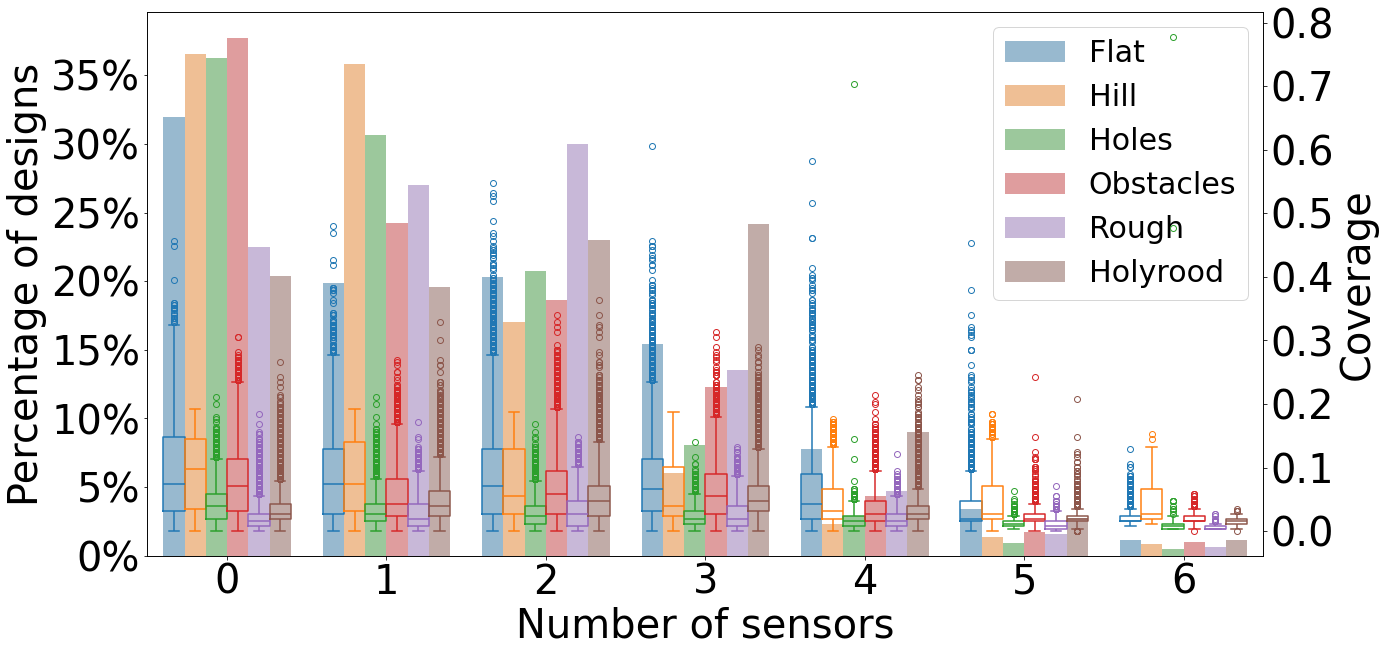

In [28]:
fig = plt.gcf()
fig.set_size_inches(20,10)
df = pd.crosstab(desc_data['environment'], desc_data['sensors'], normalize='index')
df1 = df.melt(var_name='sensors', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="sensors",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5)
ax.yaxis.label.set_size(40)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=30)
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
ax.xaxis.label.set_size(40)
ax.set_xlabel("Number of sensors")
ax.set_ylabel("Percentage of designs")
ax = plt.twinx()
sns.boxplot(data=desc_data,x="sensors",y="fitness",hue="environment",ax=ax,fill=False,legend=False)
ax.set_ylabel("Coverage")
ax.yaxis.label.set_size(40)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=40)
plt.savefig("img_alife25/distribution_sensors_score.png")

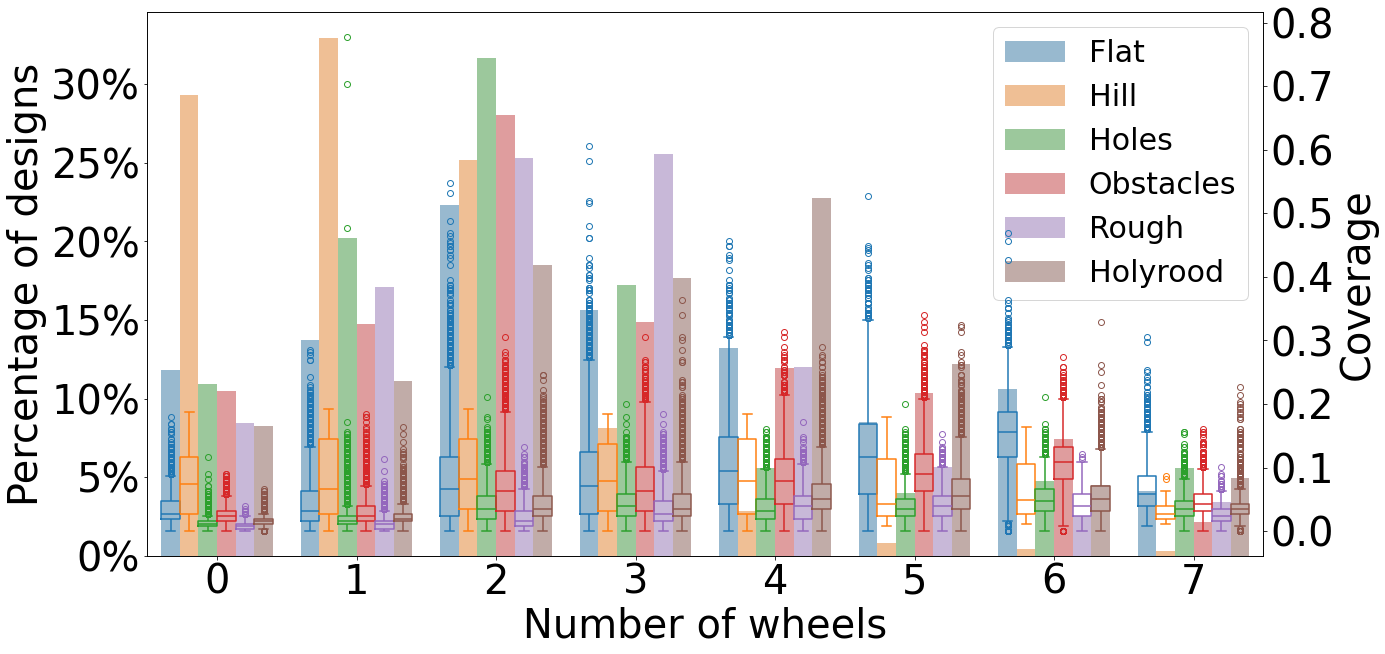

In [29]:
fig = plt.gcf()
fig.set_size_inches(20,10)
df = pd.crosstab(desc_data['environment'], desc_data['wheels'], normalize='index')
df1 = df.melt(var_name='wheels', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="wheels",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5)
ax.yaxis.label.set_size(40)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=30)
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
ax.xaxis.label.set_size(40)
ax.set_xlabel("Number of wheels")
ax.set_ylabel("Percentage of designs")
ax = plt.twinx()
sns.boxplot(data=desc_data,x="wheels",y="fitness",hue="environment",ax=ax,fill=False,legend=False)
ax.set_ylabel("Coverage")
ax.yaxis.label.set_size(40)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=40)
plt.savefig("img_alife25/distribution_wheels_score.png")

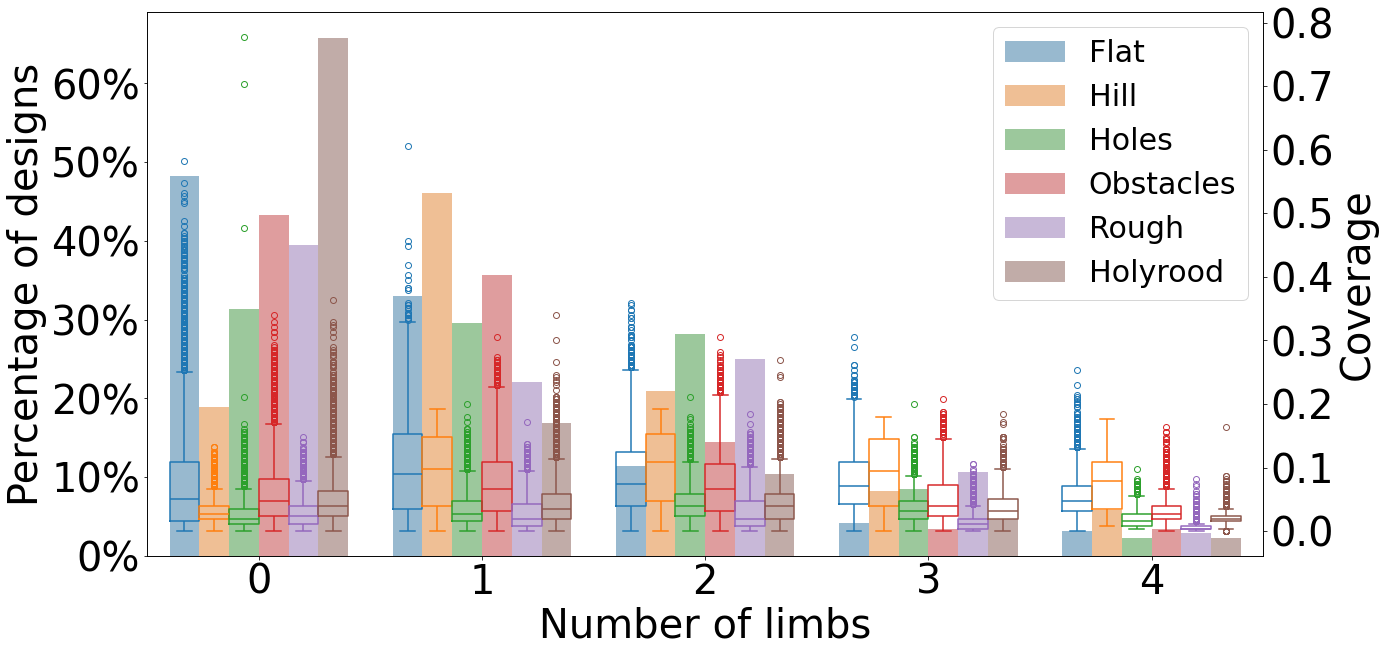

In [30]:
fig = plt.gcf()
fig.set_size_inches(20,10)
df = pd.crosstab(desc_data['environment'], desc_data['limbs'], normalize='index')
df1 = df.melt(var_name='limbs', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="limbs",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5)
ax.yaxis.label.set_size(40)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=30)
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
ax.xaxis.label.set_size(40)
ax.set_xlabel("Number of limbs")
ax.set_ylabel("Percentage of designs")
ax = plt.twinx()
sns.boxplot(data=desc_data,x="limbs",y="fitness",hue="environment",ax=ax,fill=False,legend=False)
ax.set_ylabel("Coverage")
ax.yaxis.label.set_size(40)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=40)
plt.savefig("img_alife25/distribution_limbs_score.png")

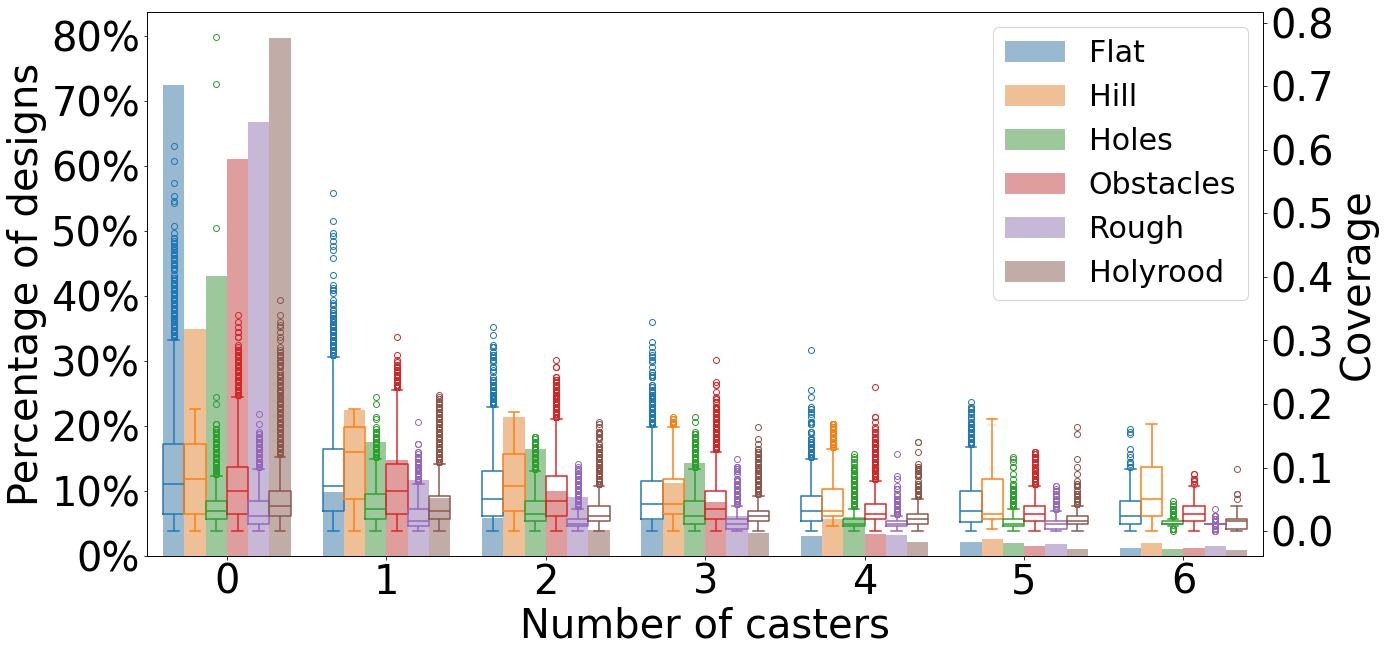

In [31]:
fig = plt.gcf()
fig.set_size_inches(20,10)
df = pd.crosstab(desc_data['environment'], desc_data['casters'], normalize='index')
df1 = df.melt(var_name='casters', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="casters",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5)
ax.yaxis.label.set_size(40)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=30)
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
ax.xaxis.label.set_size(40)
ax.set_xlabel("Number of casters")
ax.set_ylabel("Percentage of designs")
ax = plt.twinx()
sns.boxplot(data=desc_data,x="casters",y="fitness",hue="environment",ax=ax,fill=False,legend=False)
ax.set_ylabel("Coverage")
ax.yaxis.label.set_size(40)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=40)
plt.savefig("img_alife25/distribution_casters_score.png")

## High coverage diversity

In [35]:
top_percent = 0.1

df_top = []
for idx, exp in enumerate(experiments["name"]):
     df_top_tmp = desc_data[desc_data.environment.isin([exp])].sort_values(by='fitness', ascending=False)
     df_top_tmp = df_top_tmp.head(int(len(df_top_tmp)*(top_percent/100)))
     print(len(df_top_tmp))
     df_top.append(df_top_tmp) 

df_top_desc_data = pd.concat(df_top).reset_index(drop=True)
print(len(df_top_desc_data.index))

54
44
70
120
40
59
387


In [36]:
top_percent = 1

df_top = []
for idx, exp in enumerate(experiments["name"]):
     df_tmp = desc_data[desc_data.environment.isin([exp])]
     for rep in df_tmp["replicate"].drop_duplicates():
          df_tmp1 = df_tmp.loc[df_tmp["replicate"] == rep]
          df_top_tmp = df_tmp1.sort_values(by='fitness', ascending=False)
          df_top_tmp = df_top_tmp.head(int(len(df_top_tmp)*(top_percent/100)))
          print(exp,len(df_top_tmp),df_top_tmp.max()["fitness"],df_top_tmp.min()["fitness"])
          df_top.append(df_top_tmp)

df_top = pd.concat(df_top).reset_index(drop=True)
print(len(df_top.index))

flat 100 0.582031 0.273438
flat 52 0.480469 0.277344
flat 100 0.605469 0.292969
flat 100 0.527344 0.300781
flat 100 0.546875 0.265625
flat 90 0.53125 0.292969
hill 48 0.191406 0.179688
hill 100 0.191406 0.183594
hill 100 0.191406 0.179688
hill 100 0.1875 0.175781
hill 100 0.183594 0.171875
holes 100 0.199219 0.101562
holes 100 0.210938 0.109375
holes 100 0.777344 0.109375
holes 100 0.167969 0.109375
holes 100 0.210938 0.117188
holes 100 0.179688 0.113281
holes 100 0.148438 0.101562
obstacles 100 0.273438 0.195312
obstacles 100 0.269531 0.171875
obstacles 100 0.277344 0.207031
obstacles 100 0.304688 0.175781
obstacles 100 0.257812 0.1875
obstacles 100 0.277344 0.175781
obstacles 100 0.339844 0.203125
obstacles 100 0.304688 0.191406
obstacles 100 0.269531 0.203125
obstacles 100 0.3125 0.199219
obstacles 100 0.328125 0.195312
obstacles 100 0.273438 0.195312
rough 100 0.140625 0.0859375
rough 100 0.171875 0.0976562
rough 100 0.183594 0.101562
rough 100 0.148438 0.0898438
holyrood 100 0.285

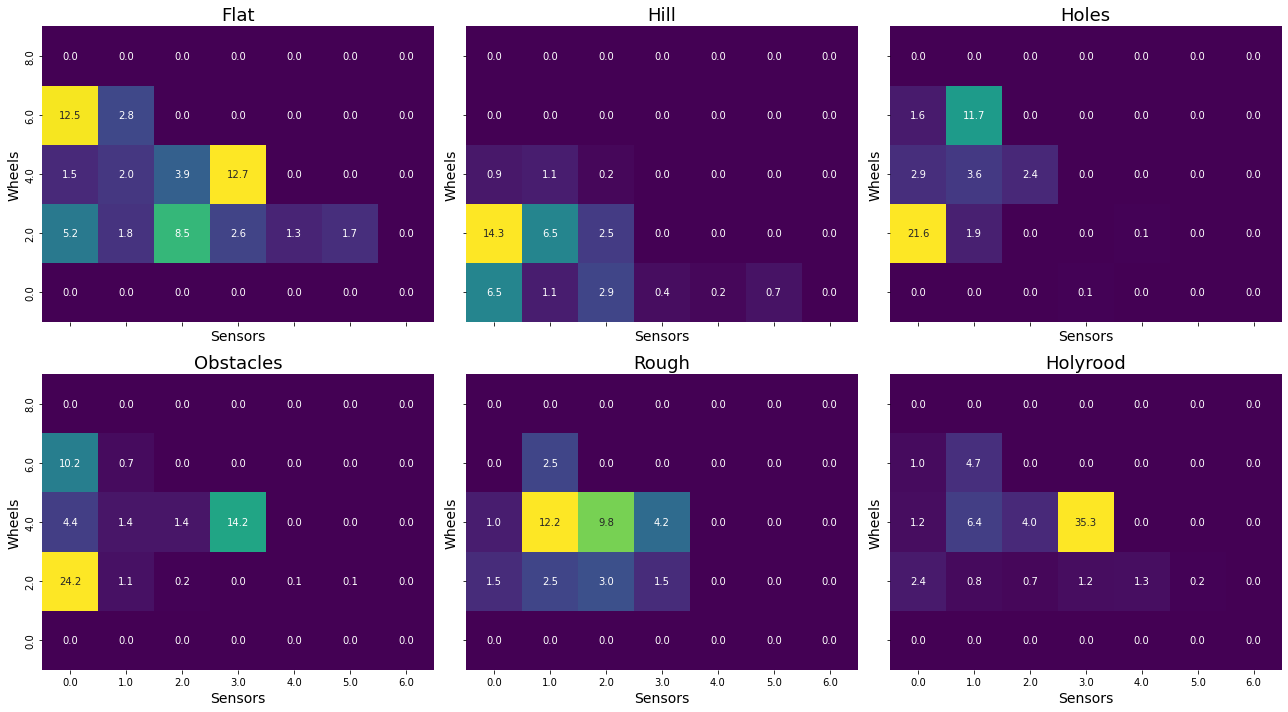

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for idx, env in enumerate(experiments["name"]):
    ax = axes[idx // 3, idx % 3]
    data = df_top[df_top["environment"] == env]
    joint_counts = pd.crosstab(data['wheels'], data['sensors'], normalize='all') * 100
    sensors_vals = sorted(df_top['sensors'].unique())
    limbs_vals = sorted(df_top['limbs'].unique())
    joint_counts = joint_counts.reindex(index=limbs_vals, columns=sensors_vals, fill_value=0.0)
    sns.heatmap(joint_counts, annot=True, fmt='.1f', cmap='viridis',
                xticklabels=True, yticklabels=True, cbar=False, ax=ax)
    ax.set_title(experiments["print_name"][idx], fontsize=18)
    ax.set_xlabel('Sensors', fontsize=14)
    ax.set_ylabel('Wheels', fontsize=14)
    ax.invert_yaxis()
    # ax.set_xticks(np.arange(0.5, 6.5, 1))
    # ax.set_yticks(np.arange(0.5, 6.5, 1))
    # ax.set_xticklabels(range(6), fontsize=12)
    # ax.set_yticklabels(range(6), fontsize=12)
    # ax.set_xlim(0, 6)
    # ax.set_ylim(6, 0)
plt.tight_layout()

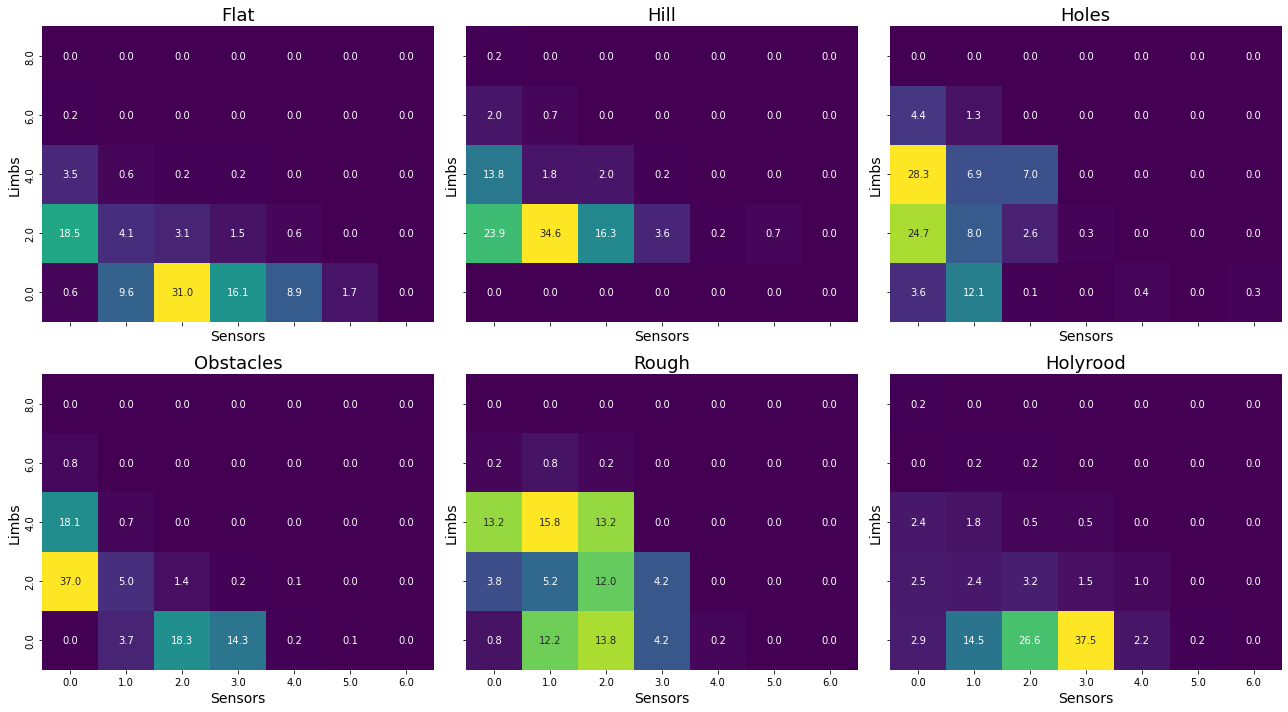

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for idx, env in enumerate(experiments["name"]):
    ax = axes[idx // 3, idx % 3]
    data = df_top[df_top["environment"] == env]
    joint_counts = pd.crosstab(data['limbs'], data['sensors'], normalize='all') * 100
    # ensure the heatmap has the same sensor/limb grid for all environments
    sensors_vals = sorted(df_top['sensors'].unique())
    limbs_vals = sorted(df_top['limbs'].unique())
    joint_counts = joint_counts.reindex(index=limbs_vals, columns=sensors_vals, fill_value=0.0)
    sns.heatmap(joint_counts, annot=True, fmt='.1f', cmap='viridis',
                xticklabels=True, yticklabels=True, cbar=False, ax=ax)
    
    ax.set_title(experiments["print_name"][idx], fontsize=18)
    ax.set_xlabel('Sensors', fontsize=14)
    ax.set_ylabel('Limbs', fontsize=14)
    ax.invert_yaxis()
    # ax.set_xticks(np.arange(0.5, 6.5, 1))
    # ax.set_yticks(np.arange(0.5, 6.5, 1))
    # ax.set_xticklabels(range(6), fontsize=12)
    # ax.set_yticklabels(range(6), fontsize=12)
plt.tight_layout()

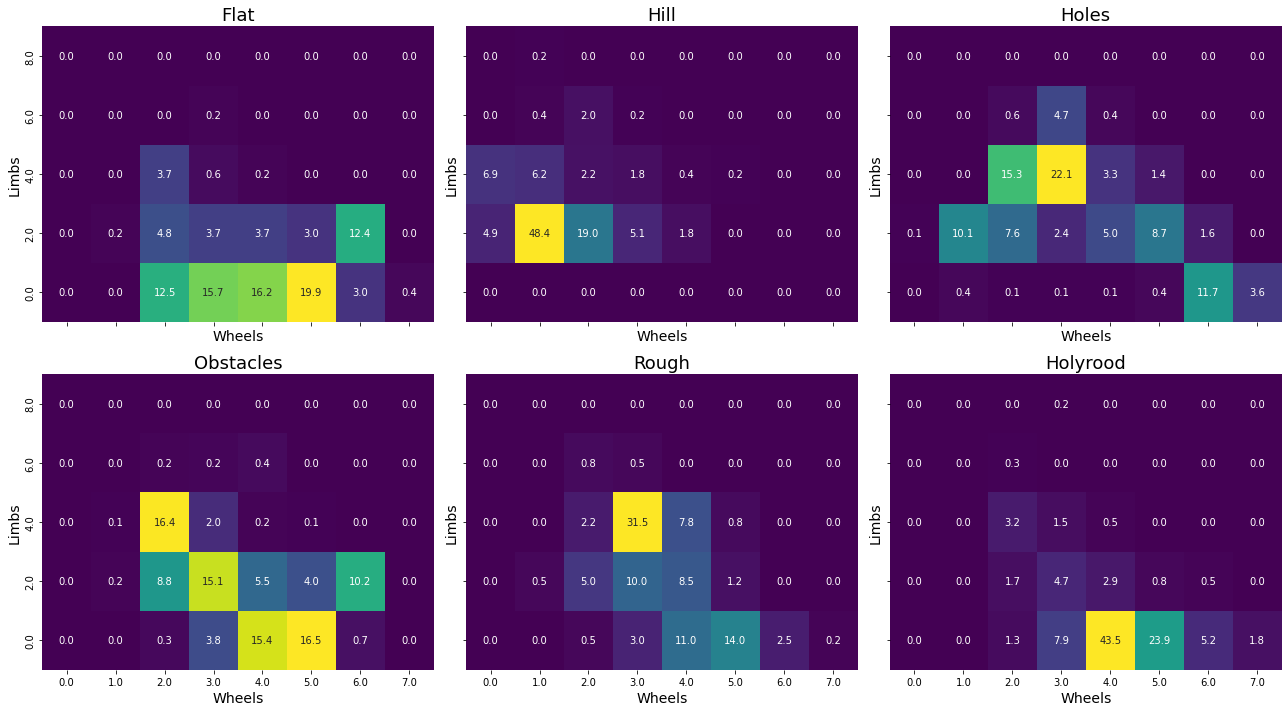

: 

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for idx, env in enumerate(experiments["name"]):
    ax = axes[idx // 3, idx % 3]
    data = df_top[df_top["environment"] == env]
    joint_counts = pd.crosstab(data['limbs'], data['wheels'], normalize='all') * 100
    # ensure the heatmap has the same sensor/limb grid for all environments
    sensors_vals = sorted(df_top['wheels'].unique())
    limbs_vals = sorted(df_top['limbs'].unique())
    joint_counts = joint_counts.reindex(index=limbs_vals, columns=sensors_vals, fill_value=0.0)
    sns.heatmap(joint_counts, annot=True, fmt='.1f', cmap='viridis',
                xticklabels=True, yticklabels=True, cbar=False, ax=ax)
    
    ax.set_title(experiments["print_name"][idx], fontsize=18)
    ax.set_xlabel('Wheels', fontsize=14)
    ax.set_ylabel('Limbs', fontsize=14)
    ax.invert_yaxis()
    # ax.set_xticks(np.arange(0.5, 6.5, 1))
    # ax.set_yticks(np.arange(0.5, 6.5, 1))
    # ax.set_xticklabels(range(6), fontsize=12)
    # ax.set_yticklabels(range(6), fontsize=12)
plt.tight_layout()

(array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]),
 [Text(0, 0.0, '0%'),
  Text(0, 0.1, '10%'),
  Text(0, 0.2, '20%'),
  Text(0, 0.30000000000000004, '30%'),
  Text(0, 0.4, '40%'),
  Text(0, 0.5, '50%'),
  Text(0, 0.6000000000000001, '60%'),
  Text(0, 0.7000000000000001, '70%')])

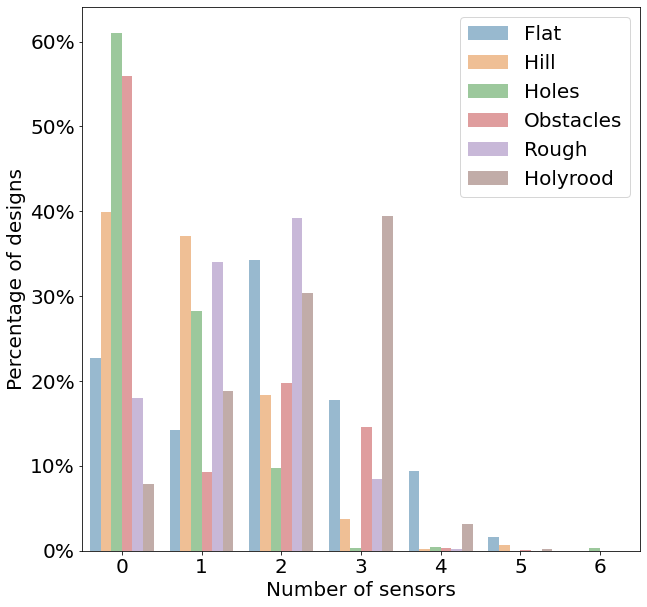

In [24]:
fig = plt.gcf()
fig.set_size_inches(10,10)
df = pd.crosstab(df_top['environment'], df_top['sensors'], normalize='index')
df1 = df.melt(var_name='sensors', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="sensors",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5)
ax.yaxis.label.set_size(20)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Number of sensors")
ax.set_ylabel("Percentage of designs")
# ax.set_xlim([-0.5,4.5])
ax.yaxis.label.set_size(20)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=20)

/tmp/ipykernel_3656353/3789371533.py:9: UserWarning: Mismatched number of handles and labels: len(handles) = 0 len(labels) = 6
  ax.legend(handles=handles,labels=experiments["print_name"],fontsize=20)
/tmp/ipykernel_3656353/3789371533.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles=handles,labels=experiments["print_name"],fontsize=20)


(array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]),
 [Text(0, 0.0, '0%'),
  Text(0, 0.1, '10%'),
  Text(0, 0.2, '20%'),
  Text(0, 0.30000000000000004, '30%'),
  Text(0, 0.4, '40%'),
  Text(0, 0.5, '50%'),
  Text(0, 0.6000000000000001, '60%')])

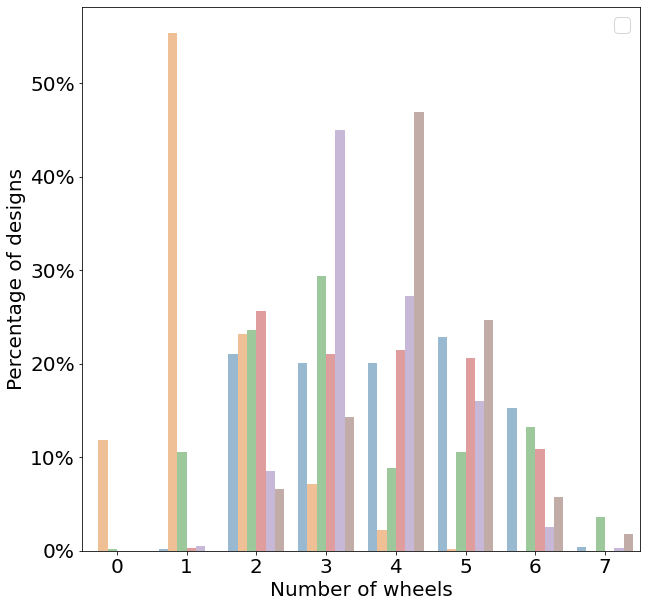

In [25]:
fig = plt.gcf()
fig.set_size_inches(10,10)
df = pd.crosstab(df_top['environment'], df_top['wheels'], normalize='index')
df1 = df.melt(var_name='wheels', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="wheels",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5,legend=False)
ax.yaxis.label.set_size(20)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Number of wheels")
ax.set_ylabel("Percentage of designs")
ax.yaxis.label.set_size(20)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=20)

(array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]),
 [Text(0, 0.0, '0%'),
  Text(0, 0.1, '10%'),
  Text(0, 0.2, '20%'),
  Text(0, 0.30000000000000004, '30%'),
  Text(0, 0.4, '40%'),
  Text(0, 0.5, '50%'),
  Text(0, 0.6000000000000001, '60%'),
  Text(0, 0.7000000000000001, '70%'),
  Text(0, 0.8, '80%'),
  Text(0, 0.9, '90%')])

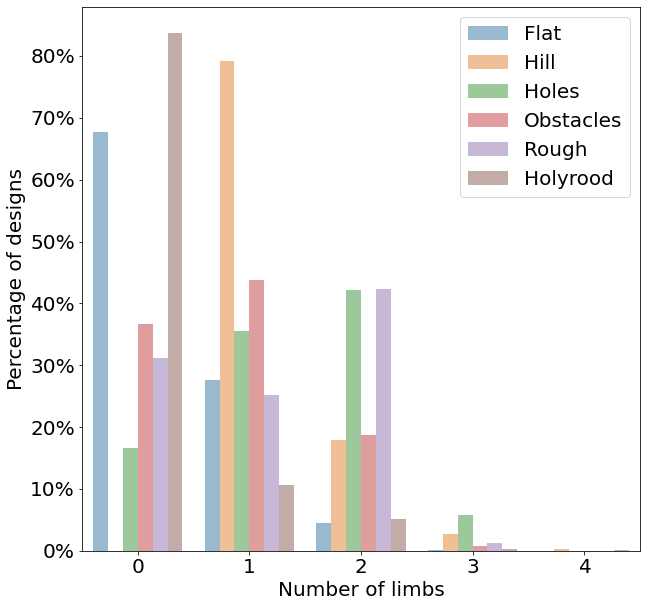

In [26]:
fig = plt.gcf()
fig.set_size_inches(10,10)
df = pd.crosstab(df_top['environment'], df_top['limbs'], normalize='index')
df1 = df.melt(var_name='limbs', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="limbs",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5)
ax.yaxis.label.set_size(20)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Number of limbs")
ax.set_ylabel("Percentage of designs")
ax.yaxis.label.set_size(20)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=20)

<Figure size 1440x360 with 0 Axes>

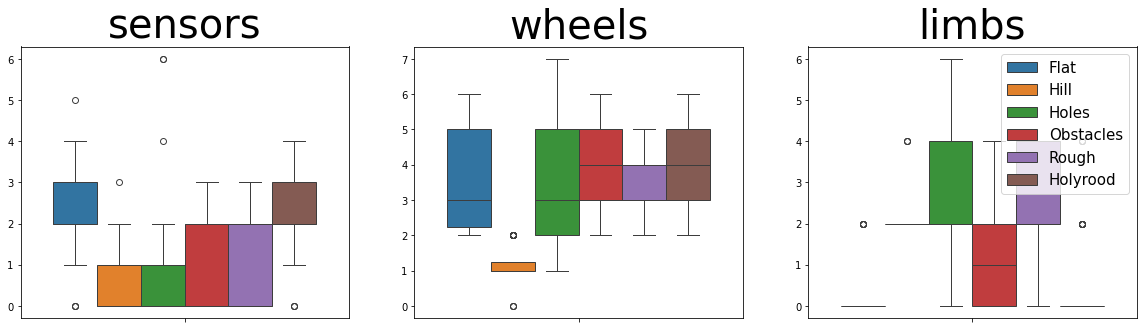

In [33]:
fig = plt.gcf()
fig.set_size_inches(20,5)
plt.figure(figsize=(20,5))
variables = ["sensors", "wheels", "limbs"]#,"casters"]
for i, c in enumerate(variables, 1):
    plt.subplot(1,3,i)
    is_legend = False
    if i == 3:
        is_legend = True
    sns.boxplot(y=c, hue="environment", data=df_top_desc_data, legend=is_legend)
    if i == 3:
      plt.legend(loc='upper right', fontsize=15, labels=experiments["print_name"])
    plt.title(c, fontsize=40)
    plt.ylabel("")
    #plt.suptitle("Top " + str(top_percent) + "%", fontsize=32)
#plt.savefig("img_alife25/high_coverage_diversity_" + str(top_percent) + ".png", bbox_inches='tight')
plt.savefig("img_alife25/features_top1_fitness.png")

In [34]:
# Window of 10% ordered by fitness
windows = 10
window_size = []
for idx, exp in enumerate(experiments["name"]):
    window_size.append(int(desc_data[desc_data.environment.isin([exp])].shape[0] / windows))
feats = ["wheels", "sensors", "limbs"]
wheels = []
sensors = []
limbs = []
full_data = []
for window in range(windows):
    temp = []
    for idx, exp in enumerate(experiments["name"]):
        temp = desc_data[desc_data.environment.isin([exp])].sort_values(by=['fitness'], ascending=True)[window_size[idx] * window : window_size[idx] * (window + 1)]
        temp["window"] = window
        full_data.append(temp)
        # wheels.append([temp.wheels.mean(), temp.wheels.std(), temp.wheels.median(), temp.wheels.mode()[0], temp.wheels.quantile(0.75) - temp.wheels.quantile(0.25), temp.wheels.var(), window, exp, "wheels"])
        # sensors.append([temp.sensors.mean(), temp.sensors.std(), temp.sensors.median(), temp.sensors.mode()[0], temp.sensors.quantile(0.75) - temp.sensors.quantile(0.25), temp.sensors.var(), window, exp, "sensors"])
        # limbs.append([temp.limbs.mean(), temp.limbs.std(), temp.limbs.median(), temp.limbs.mode()[0], temp.limbs.quantile(0.75) - temp.limbs.quantile(0.25), temp.limbs.var(), window, exp, "limbs"])

wheels = pd.DataFrame(data=wheels, columns=["mean", "std", "median", "mode", "IQR", "var",  "window", "environment", "feature"])
sensors = pd.DataFrame(data=sensors, columns=["mean", "std", "median", "mode", "IQR", "var",  "window", "environment", "feature"])
limbs = pd.DataFrame(data=limbs, columns=["mean", "std", "median", "mode", "IQR", "var",  "window", "environment", "feature"])
windowed_data_fitness = pd.concat(full_data).reset_index(drop=True)#pd.concat([wheels, sensors, limbs]).reset_index(drop=True)
#windowed_data = pd.DataFrame(data=windowed_data, columns=["mean", "window", "environment", "feature"])
#print(windowed_data)

<Figure size 576x1440 with 0 Axes>

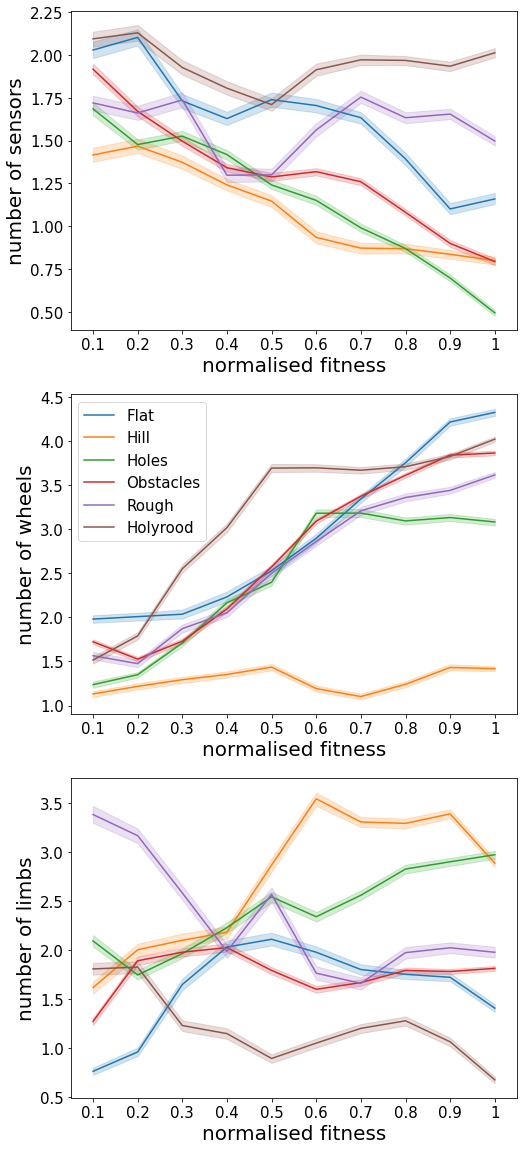

In [35]:
fig = plt.gcf()
fig.set_size_inches(8,20)
plt.figure(figsize=(8,20))
variables = [ "sensors", "wheels", "limbs"]#,"casters"]
for i, c in enumerate(variables, 1):
    plt.subplot(3,1,i)
    is_legend = False
    if i == 2:
        is_legend = True
    ax = sns.lineplot(data=windowed_data_fitness, x="window", y=c, hue="environment", legend=is_legend)
    if(is_legend):
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles=handles,loc='upper left', fontsize=15, labels=experiments["print_name"],title="")
    # plt.title(c, fontsize=20)
    plt.ylabel(f"number of {c}",fontsize=20)
    plt.xlabel("normalised fitness",fontsize=20)
    plt.xlim(-0.5, 9.5)
    plt.xticks([0,1,2,3,4,5,6,7,8,9], ['0.1','0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '1'],fontsize=15)
    plt.yticks(fontsize=15)


    #plt.suptitle("Top " + str(top_percent) + "%", fontsize=32)
plt.savefig("img_alife25/features_trend_fitness.png", bbox_inches='tight')

<Figure size 2160x360 with 0 Axes>

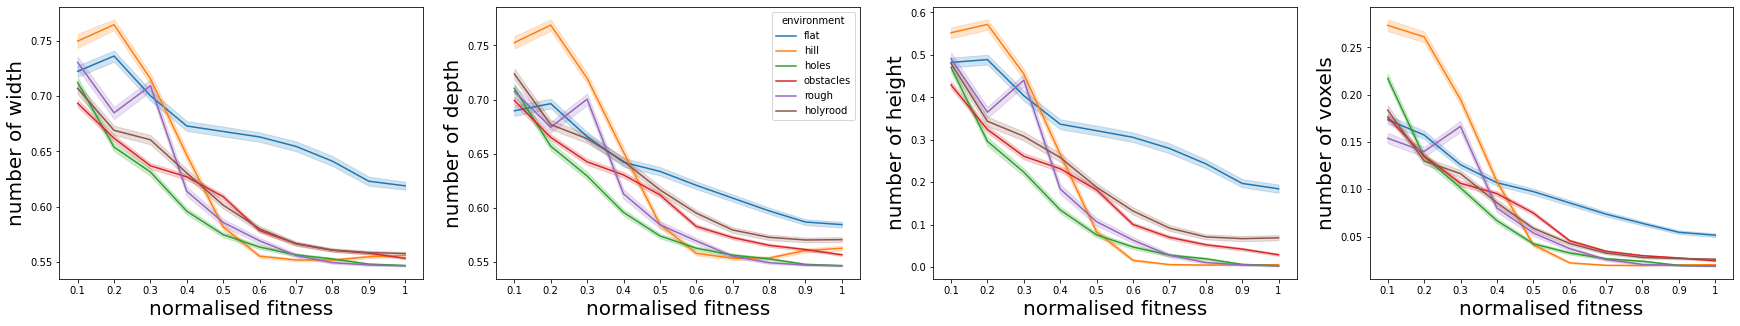

In [36]:
fig = plt.gcf()
fig.set_size_inches(30,5)
plt.figure(figsize=(30,5))
variables = [ "width", "depth", "height", "voxels"]#,"casters"]
for i, c in enumerate(variables, 1):
    plt.subplot(1,4,i)
    is_legend = False
    if i == 2:
        is_legend = True
        plt.legend(loc='upper left', fontsize=15, labels=experiments["print_name"])
    #ax = sns.lineplot(data=windowed_data_fitness[windowed_data_fitness["feature"] == c], x="window", y="mean", hue="environment", legend=is_legend)
    ax = sns.lineplot(data=windowed_data_fitness, x="window", y=c, hue="environment", legend=is_legend)
    plt.ylabel(f"number of {c}",fontsize=20)
    plt.xlabel("normalised fitness",fontsize=20)
    plt.xlim(-0.5, 9.5)
    plt.xticks([0,1,2,3,4,5,6,7,8,9], ['0.1','0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '1'])

    #plt.suptitle("Top " + str(top_percent) + "%", fontsize=32)
plt.savefig("img_alife25/features_trend_fitness.png", bbox_inches='tight')
plt.savefig("img_alife25/features_trend_fitness.png", bbox_inches='tight')

In [37]:
# Window of 10% ordered by replicate index
windows = 10
window_size = []
for idx, exp in enumerate(experiments["name"]):
    window_size.append(int(desc_data[desc_data.environment.isin([exp])].shape[0] / windows))
feats = ["wheels", "sensors", "limbs"]
wheels = []
sensors = []
limbs = []
full_data = []
for window in range(windows):
    temp = []
    for idx, exp in enumerate(experiments["name"]):
        temp = desc_data[desc_data.environment.isin([exp])].sort_values(by=['replicate_index'], ascending=True)[window_size[idx] * window : window_size[idx] * (window + 1)]
        temp["window"] = window
        full_data.append(temp)
        wheels.append([temp.wheels.mean(), temp.wheels.std(), temp.wheels.median(), temp.wheels.mode()[0], temp.wheels.quantile(0.75) - temp.wheels.quantile(0.25), temp.wheels.var(), window, exp, "wheels"])
        sensors.append([temp.sensors.mean(), temp.sensors.std(), temp.sensors.median(), temp.sensors.mode()[0], temp.sensors.quantile(0.75) - temp.sensors.quantile(0.25), temp.sensors.var(), window, exp, "sensors"])
        limbs.append([temp.limbs.mean(), temp.limbs.std(), temp.limbs.median(), temp.limbs.mode()[0], temp.limbs.quantile(0.75) - temp.limbs.quantile(0.25), temp.limbs.var(), window, exp, "limbs"])

wheels = pd.DataFrame(data=wheels, columns=["mean", "std", "median", "mode", "IQR", "var",  "window", "environment", "feature"])
sensors = pd.DataFrame(data=sensors, columns=["mean", "std", "median", "mode", "IQR", "var",  "window", "environment", "feature"])
limbs = pd.DataFrame(data=limbs, columns=["mean", "std", "median", "mode", "IQR", "var",  "window", "environment", "feature"])
windowed_data_generation = pd.concat(full_data).reset_index(drop=True) #pd.concat([wheels, sensors, limbs]).reset_index(drop=True)

#windowed_data = pd.DataFrame(data=windowed_data, columns=["mean", "window", "environment", "feature"])
#print(windowed_data)

<Figure size 576x1440 with 0 Axes>

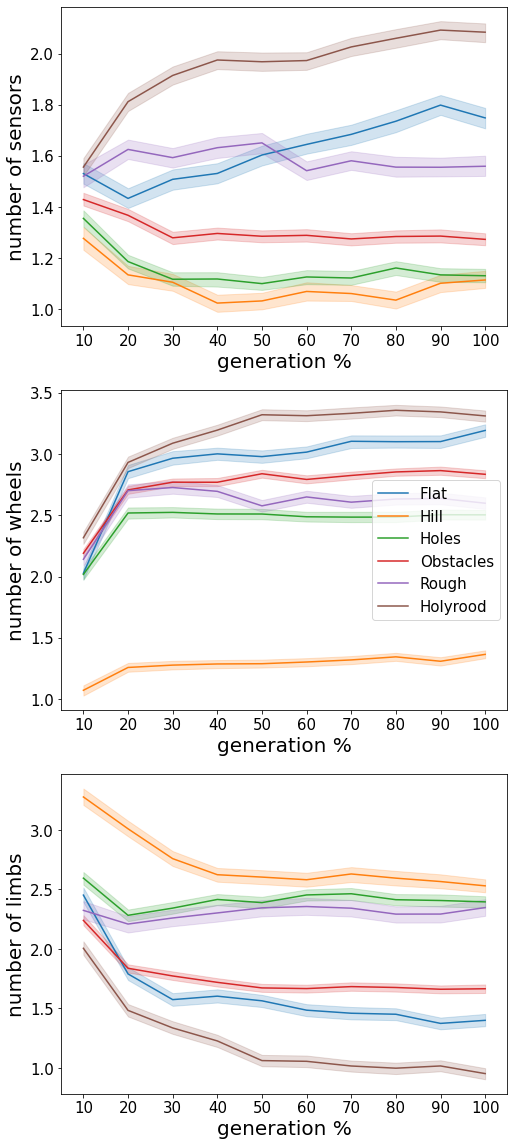

In [38]:
fig = plt.gcf()
fig.set_size_inches(8,20)
plt.figure(figsize=(8,20))
variables = [ "sensors", "wheels", "limbs"]#,"casters"]
for i, c in enumerate(variables, 1):
    plt.subplot(3,1,i)
    is_legend = False
    if i == 2:
        is_legend = True
    #ax = sns.scatterplot(data=windowed_data_generation[windowed_data_generation["feature"] == c], x="window", y="mean", hue="environment", legend=is_legend)
    ax = sns.lineplot(data=windowed_data_generation, x="window", y=c, hue="environment", legend=is_legend)
    if(is_legend):
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles=handles,loc='center right', fontsize=15, labels=experiments["print_name"],title="")
    #plt.legend(loc='upper left', fontsize=15, labels=experiments["print_name"])
    #ax.errorbar(windowed_data[windowed_data["feature"] == c]["window"], windowed_data[windowed_data["feature"] == c]["mean"], yerr= windowed_data[windowed_data["feature"] == c]["std"],fmt='o')
    
    plt.ylabel(f"number of {c}",fontsize=20)
    plt.xlabel("generation %",fontsize=20)
    plt.xlim(-0.5, 9.5)
    plt.xticks([0,1,2,3,4,5,6,7,8,9], ['10','20', '30', '40', '50', '60', '70', '80', '90', '100'],fontsize=15)
    plt.yticks(fontsize=15)

    #plt.suptitle("Top " + str(top_percent) + "%", fontsize=32)
plt.savefig("img_alife25/features_trend_generation.png", bbox_inches='tight')

<Figure size 2160x360 with 0 Axes>

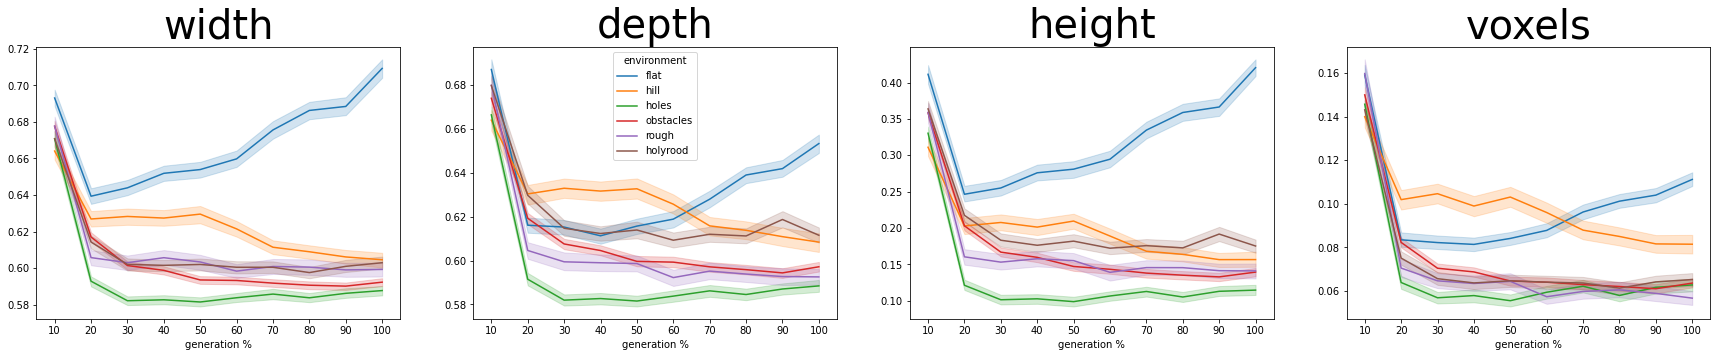

In [39]:
fig = plt.gcf()
fig.set_size_inches(30,5)
plt.figure(figsize=(30,5))
variables = [ "width", "depth", "height", "voxels"]#,"casters"]
for i, c in enumerate(variables, 1):
    plt.subplot(1,4,i)
    is_legend = False
    if i == 2:
        is_legend = True
        plt.legend(loc='upper left', fontsize=15, labels=experiments["print_name"])
    #ax = sns.scatterplot(data=windowed_data_generation[windowed_data_generation["feature"] == c], x="window", y="mean", hue="environment", legend=is_legend)
    ax = sns.lineplot(data=windowed_data_generation, x="window", y=c, hue="environment", legend=is_legend)
    #plt.legend(loc='upper left', fontsize=15, labels=experiments["print_name"])
    #ax.errorbar(windowed_data[windowed_data["feature"] == c]["window"], windowed_data[windowed_data["feature"] == c]["mean"], yerr= windowed_data[windowed_data["feature"] == c]["std"],fmt='o')
    
    plt.title(c, fontsize=40)
    plt.ylabel("")
    plt.xlabel("generation %")
    plt.xlim(-0.5, 9.5)
    plt.xticks([0,1,2,3,4,5,6,7,8,9], ['10','20', '30', '40', '50', '60', '70', '80', '90', '100'])

    #plt.suptitle("Top " + str(top_percent) + "%", fontsize=32)
# plt.savefig("img_alife25/features_trend_generation.png", bbox_inches='tight')

(array([ 0.,  2.,  4.,  6.,  8., 10., 12.]),
 [Text(0, 0.0, '0'),
  Text(0, 2.0, '2'),
  Text(0, 4.0, '4'),
  Text(0, 6.0, '6'),
  Text(0, 8.0, '8'),
  Text(0, 10.0, '10'),
  Text(0, 12.0, '12')])

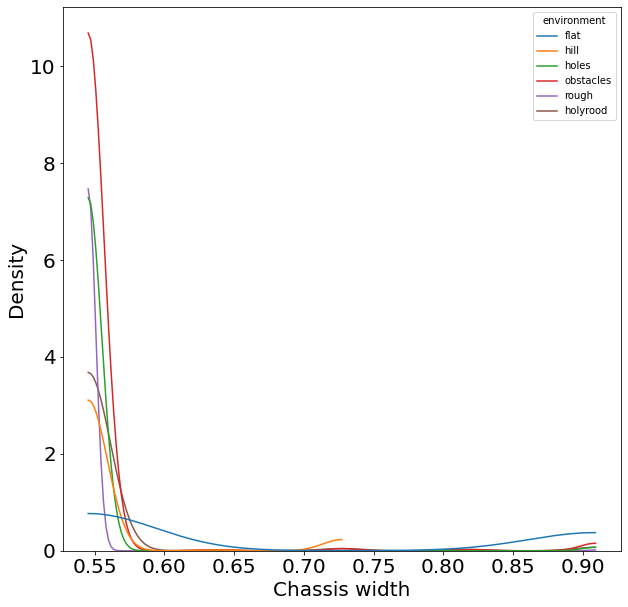

In [51]:
fig = plt.gcf()
fig.set_size_inches(10,10)
ax = sns.kdeplot(data=df_top,x="width",hue="environment",cut=0,hue_order=experiments["name"])
ax.yaxis.label.set_size(20)
#plt.legend(["flat","terrain 1","terrain 2","terrain 3"],fontsize=20,loc=2)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Chassis width")
ax.yaxis.label.set_size(20)
plt.yticks(fontsize=20)

(array([0., 1., 2., 3., 4., 5., 6.]),
 [Text(0, 0.0, '0'),
  Text(0, 1.0, '1'),
  Text(0, 2.0, '2'),
  Text(0, 3.0, '3'),
  Text(0, 4.0, '4'),
  Text(0, 5.0, '5'),
  Text(0, 6.0, '6')])

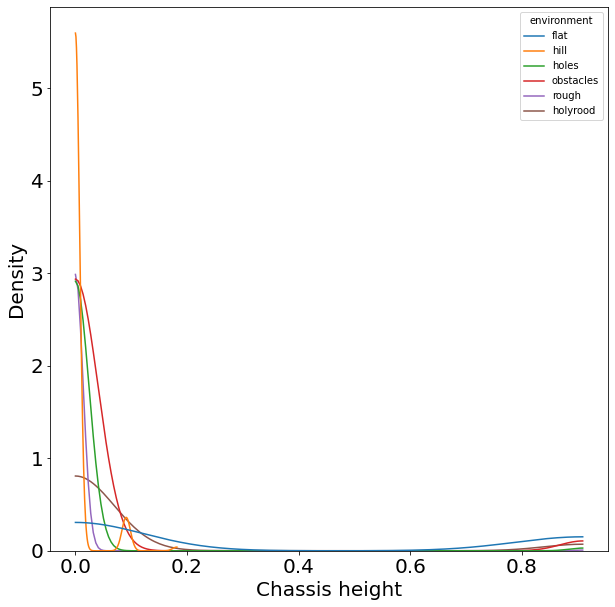

In [52]:
fig = plt.gcf()
fig.set_size_inches(10,10)
ax = sns.kdeplot(data=df_top,x="height",hue="environment",cut=0)
ax.yaxis.label.set_size(20)
#plt.legend(["flat","terrain 1","terrain 2","terrain 3"],fontsize=20,loc=2)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Chassis height")
ax.yaxis.label.set_size(20)
plt.yticks(fontsize=20)

(array([ 0.,  2.,  4.,  6.,  8., 10., 12., 14., 16.]),
 [Text(0, 0.0, '0'),
  Text(0, 2.0, '2'),
  Text(0, 4.0, '4'),
  Text(0, 6.0, '6'),
  Text(0, 8.0, '8'),
  Text(0, 10.0, '10'),
  Text(0, 12.0, '12'),
  Text(0, 14.0, '14'),
  Text(0, 16.0, '16')])

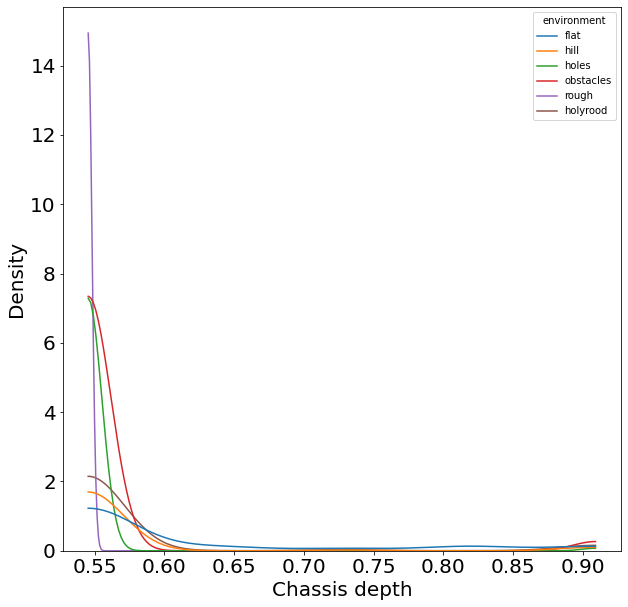

In [53]:
fig = plt.gcf()
fig.set_size_inches(10,10)
ax = sns.kdeplot(data=df_top,x="depth",hue="environment",cut=0)
ax.yaxis.label.set_size(20)
#plt.legend(["flat","terrain 1","terrain 2","terrain 3"],fontsize=20,loc=2)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Chassis depth")
ax.yaxis.label.set_size(20)
plt.yticks(fontsize=20)

(array([ 0.,  5., 10., 15., 20., 25.]),
 [Text(0, 0.0, '0'),
  Text(0, 5.0, '5'),
  Text(0, 10.0, '10'),
  Text(0, 15.0, '15'),
  Text(0, 20.0, '20'),
  Text(0, 25.0, '25')])

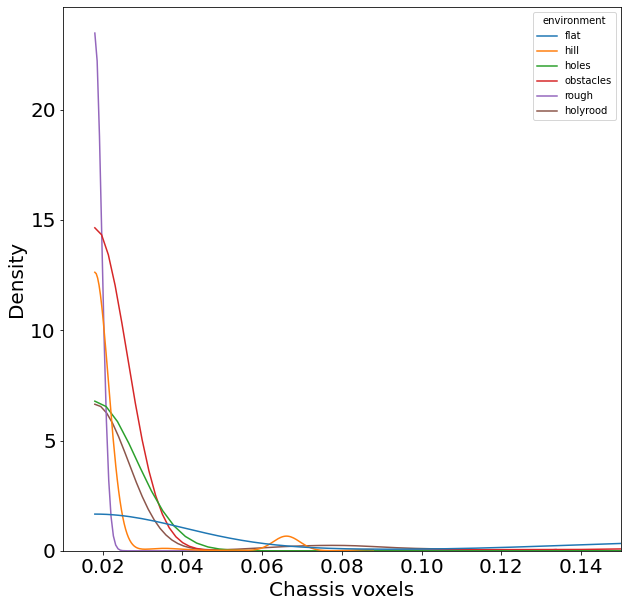

In [54]:
fig = plt.gcf()
fig.set_size_inches(10,10)
ax = sns.kdeplot(data=df_top,x="voxels",hue="environment",cut=0)
ax.yaxis.label.set_size(20)
#plt.legend(["flat","terrain 1","terrain 2","terrain 3"],fontsize=20,loc=2)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlim(0.01,0.15)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Chassis voxels")
ax.yaxis.label.set_size(20)
plt.yticks(fontsize=20)

## Chassis diversity

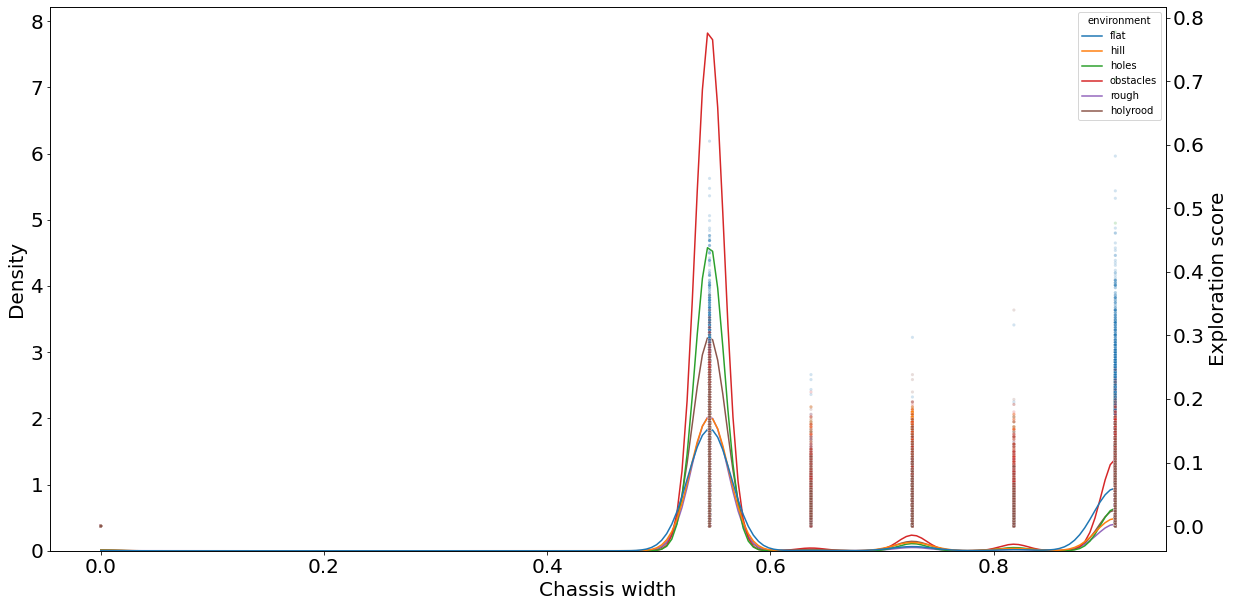

In [40]:
fig = plt.gcf()
fig.set_size_inches(20,10)
ax = sns.kdeplot(data=desc_data,x="width",hue="environment",cut=0,hue_order=experiments["name"])
ax.yaxis.label.set_size(20)
#plt.legend(["flat","terrain 1","terrain 2","terrain 3"],fontsize=20,loc=2)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Chassis width")
ax = plt.twinx()
sns.scatterplot(data=desc_data,x="width",y="fitness",hue="environment",ax=ax,s=10,legend=False,alpha=0.2,hue_order=experiments["name"])
ax.set_ylabel("Coverage")
ax.set_ylabel("Exploration score")
ax.yaxis.label.set_size(20)
plt.yticks(fontsize=20)
plt.savefig("img_alife25/distribution_chassis_width.png", bbox_inches='tight')

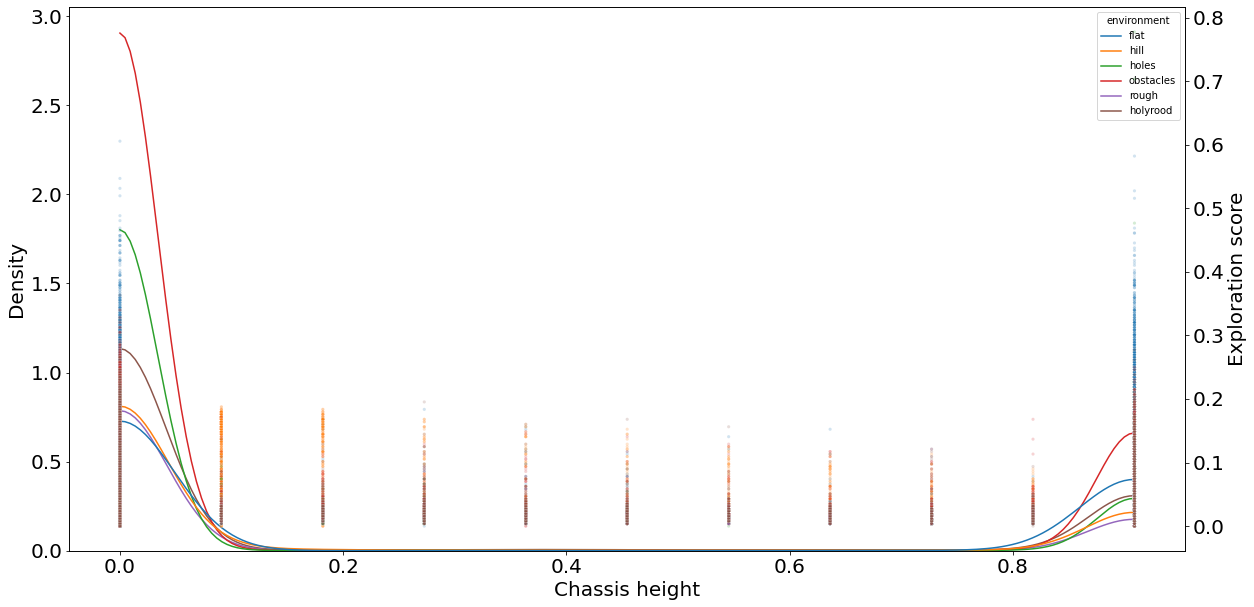

In [41]:
fig = plt.gcf()
fig.set_size_inches(20,10)
ax = sns.kdeplot(data=desc_data,x="height",hue="environment",cut=0)
ax.yaxis.label.set_size(20)
#plt.legend(["flat","terrain 1","terrain 2","terrain 3"],fontsize=20,loc=2)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Chassis height")
ax = plt.twinx()
sns.scatterplot(data=desc_data,x="height",y="fitness",hue="environment",ax=ax,s=10,legend=False,alpha=0.2)
ax.set_ylabel("Exploration score")
ax.yaxis.label.set_size(20)
plt.yticks(fontsize=20)
plt.savefig("img_alife25/distribution_chassis_height.png", bbox_inches='tight')

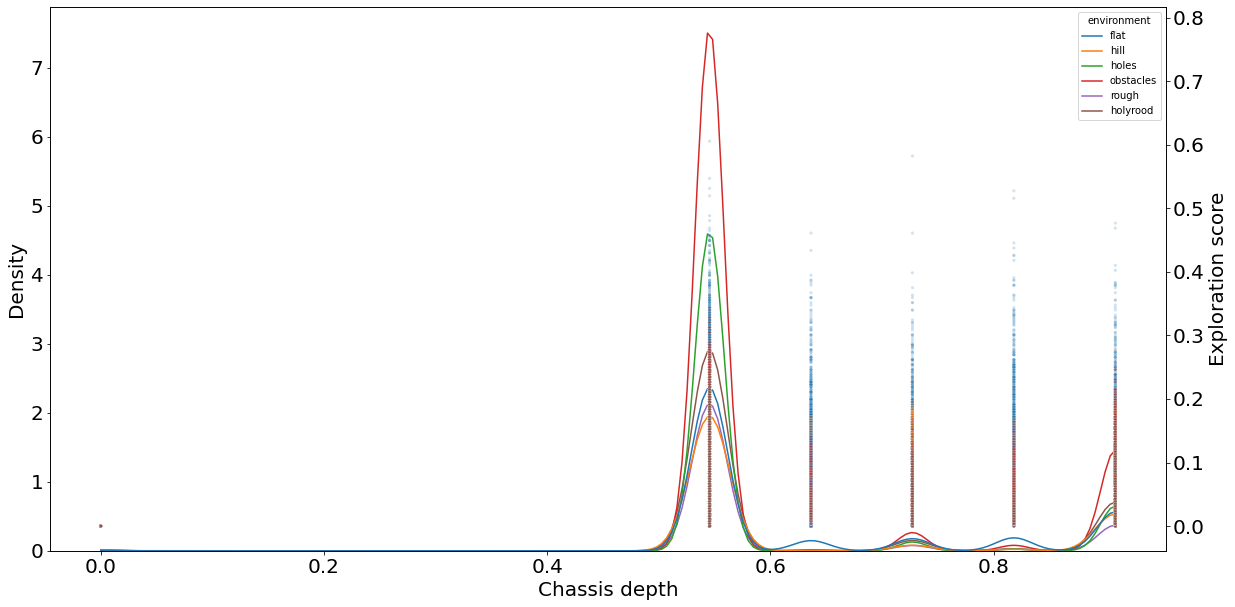

In [42]:
fig = plt.gcf()
fig.set_size_inches(20,10)
ax = sns.kdeplot(data=desc_data,x="depth",hue="environment",cut=0)
ax.yaxis.label.set_size(20)
#plt.legend(["flat","terrain 1","terrain 2","terrain 3"],fontsize=20,loc=2)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Chassis depth")
ax = plt.twinx()
sns.scatterplot(data=desc_data,x="depth",y="fitness",hue="environment",ax=ax,s=10,legend=False,alpha=0.2)
ax.set_ylabel("Exploration score")
ax.yaxis.label.set_size(20)
plt.yticks(fontsize=20)
plt.savefig("img_alife25/distribution_chassis_depth.png", bbox_inches='tight')

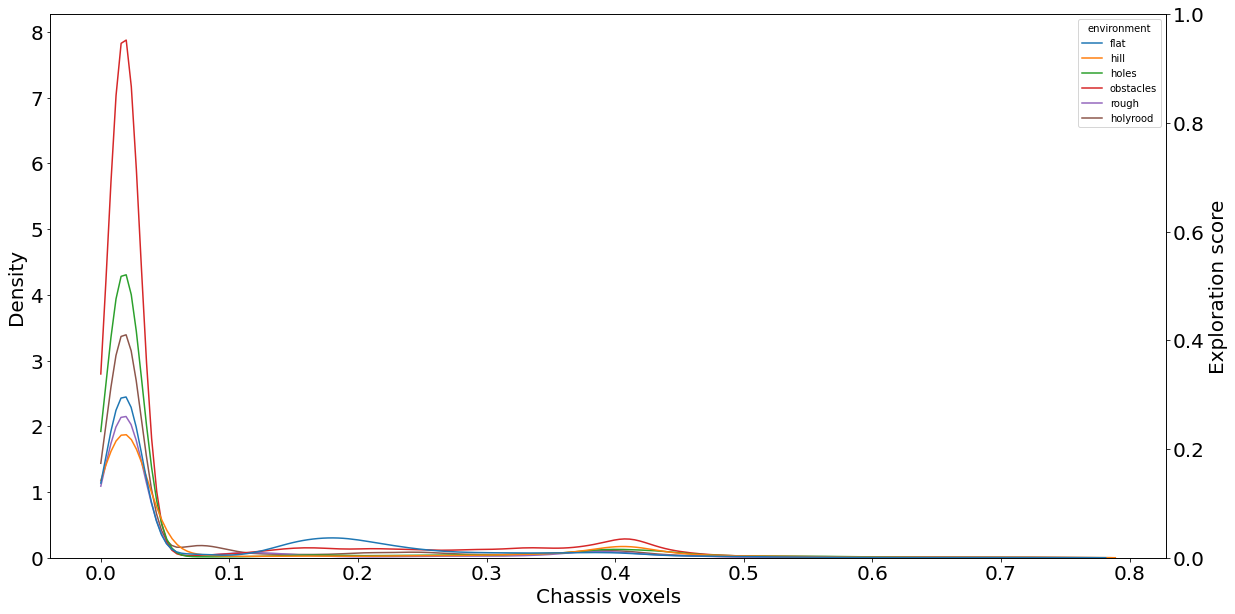

In [43]:
fig = plt.gcf()
fig.set_size_inches(20,10)
sns.scatterplot(data=desc_data,x="voxels",y="fitness",hue="environment",ax=ax,s=10,legend=False,alpha=0.2)
ax = sns.kdeplot(data=desc_data,x="voxels",hue="environment",cut=0)
ax.yaxis.label.set_size(20)
#plt.legend(["flat","terrain 1","terrain 2","terrain 3"],fontsize=20,loc=2)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Chassis voxels")
ax = plt.twinx()
ax.set_ylabel("Exploration score")
ax.yaxis.label.set_size(20)
plt.yticks(fontsize=20)
plt.savefig("img_alife25/distribution_chassis_voxels.png", bbox_inches='tight')